<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue">**Quantum Computing**

In [ ]:
!pip install cirq openfermion -q
import cirq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###### <font color="blue">*Quantum Dynamics*

<font color="blue">**Schrödinger Equation  $|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle$**

Quantum systems in chemistry and physics can be described and computed with either classical and quantum methods:

* **Model**: Classical (Newton Mechanics) vs Quantum (Schrödinger equation)
* **Type**: Static (State) vs Dynamical (Evolution)
* **Computing**: Classical Computing vs Quantum Computing

<font color="blue">*1. Classical (Newtonian) Mechanics (**Static and Dynamic**): $F = m \cdot a$*
* Ignores electrons and consider atoms as spheres connected by springs (force fields)
* **Classical - Dynamic**: Molecular dynamics (MD). How proteins enfold and move? GROMACS, NAMD, AMBER.
* **Classical - Static**: Molecular Docking / Energy Minimization. Geometrically: Does medication fit to enzyme? AutoDock, Rosetta.
* **Quantum computing methods:** Future: Navier Stokes (fluid dynamics) with HHL to solve linear systems and differential equations exponentially faster than classical computers. For weather and climate: simulate weather with a much finer grid (e.g. 100m)

<font color="blue">*2. Quantum Mechanics (**Static**): Time-independent Schrödinger Equation $\hat{H}|\psi\rangle = E|\psi\rangle$*
* Includes electrons. **Approximates Ground State via optimization** with variation $\delta \langle H \rangle = 0$ to find global optimum in energy landscape. Stationary state important for calculating binding energies: If $\psi$ is an eigenstate of $\hat{H}$, then time evolution is trivial: $\Psi(t) = \psi e^{-iEt/\hbar}$. Probability density $|\Psi(t)|^2$ remains constant over time = states are stationary.
* **Classical computing:** Hartree-Fock (mean field of $\psi$) but ignore correlation energies, DFT (electron density $\rho$) approximates correlation energies with functionals (but require correct functional assumed), Post-HF (Coupled cluster, configuration interaction) calculate correlation energies but only small systems since their complexity grows exponentially
* **Quantum computing** (**NISQ**): Variational Quantum Eigensolver. Quantum Advantage: finds correlation energy with entanglement.
  * In classical quantum chemistry, correlation energies are either ignored (HF), approximated (DFT), or, while theoretically calculable exactly, are only feasible for small quantum systems (post-Hartree-Fock methods like coupled cluster or configuration interaction).
  * For classical computers, complexity grows exponentially, this is why quantum computers will play a significant role in analyzing larger, more complex systems.

<font color="blue">*3. Quantum Mechanics (**Dynamic**): Time-dependent Schrödinger Equation $i\hbar \frac{\partial}{\partial t} \Psi(\mathbf{r}, t) = \hat{H} \Psi(\mathbf{r}, t)$*
* **Simulate Time Evolution** $e^{-i\hat{H}t}$ of Quantum State $|\Psi(t)\rangle = e^{-i\hat{H}t/\hbar} |\Psi(0)\rangle$ via Unitary Transformation. For Quantum Chaos, OTOC, Scrambling (Black Holes) reaction dynamics (observe how bonds break and reform during a collision). No forward theorem!
* **Classical computing**: Time-Dependent DFT (TD-DFT) used to classically calculate excitations (fluorescence, spectra). However only for short times and small systems. To solve the time-dependent equation $i\hbar \frac{\partial}{\partial t} \Psi = \hat{H} \Psi$ classically at scale, you have to apply operator $e^{-i\hat{H}t/\hbar}$ to wavefunction. In system with $N$ particles, complexity grows exponentially with $N$.
* **Quantum computing** (**Fault-Tolerant**): Central challenge in quantum dynamics (Simulating Quantum Time Evolution):
  * Molecule evolves under all its forces (Kinetic + Potential) simultaneously, but QC can only do one. But unitary propagator $U(t) = e^{-i\hat{H}t}$ is implemented on quantum hardware that only supports a discrete set of elementary gates at once.
  * Three approaches: LCU, Trotterization, Qubitization (with Quantum Walks and Block Encoding). And with the OTOC metric to measure information scrambling during quantum evolution (https://research.google/blog/a-verifiable-quantum-advantage/)


<font color="blue">*Appendix: Why we can solve the Schrödinger equation analytically only for very small systems (Quantum Chemistry)*
* **Analytical** solution for Schrödinger in Hydrogen atom. But a second electron add electron-electron repulsion = three-body problem.
* **Approximate** Schrödinger with DFT and HF on classical computers via **optimization (variation)** for larger systems than Hydrogen
* **Simulate** time evolution for even larger systems = Quantum computer doesn't store information anymore - **it is the Hilbert space!**
* Weil die Schrödinger Gleichung nicht exakt lösbar für größere Systeme: Rayleigh Ritz Verfahren aus Variationsanalyse und Born-Oppenheimer Aporoximation (Nukleus fixed, Elektronen für Energy Potential). Modelle und Verfahren:
  * Valenzbindungstheorie (Hybridisierung, lokale Bindungen)
  * Molekülorbitaltheorie (Delokalisierung, Konjugation, Homo/Lumo, LCAO-Methode)
  * Hartee-Fock, Post-Hartree Fock (correlation energies), DFT
  * Quantum Numbers (Besonderheit: Spinquantenzahl. Normale“ Schrödinger-Gleichung liefert nur $n$, $l$ und $m_l$. Spin ($m_s$=± 1/2) quanten- mechanische Eigenschaft. Erscheint wenn Quantenmechanik + Speziellen RT kombiniert (1928 Dirac-Gleichung).


In [ ]:
# @title Qubitization: Quantum Walk, Block Encoding, LCU
# ==========================================
# OTOC (Quantum Implementation)
# ==========================================
from IPython.display import display, Markdown

print(40*"=")
print("Qubitization (Quantum Walk, Block Encoding, LCU)")
print(40*"=")

display(Markdown(r"* Qubitization is an algebraic trick. It transforms the problem of walking through time into a problem of walking through the eigenvalues of an operator."))
display(Markdown(r"* **LCU Decomposition:** Approximate operator by decomposing propagator $e^{-iHt}$ via Taylor series in weightes sum of unitaries $H = \sum_{l=0}^{L-1} \alpha_l U_l$. (non-unitary, represents energy). Then **Normalization:** $\lambda = \sum |\alpha_k|$ $\rightarrow$ $H/\lambda$. If $H=$ Dirac $\mathcal{D}$ = as benchmark, its algebraic structure (sum of Paulis) efficient."))
display(Markdown(r"* **LCU Oracles**: 1. ***PREPARE Oracle*** ($P$): encodes coefficients $\alpha_j$ into amplitudes of ancilla. Output is state where probability of measuring state $j$ is proportional to $\alpha_j$: $P|0\rangle = \frac{1}{\sqrt{\|\alpha\|_1}} \sum_{j=0}^{m-1} \sqrt{\alpha_j} |j\rangle$. ***2. SELECT Oracle*** ($S$) apply unitaries $U_l$ to target register state, conditioned on state of ancilla (entangles). If ancilla is state $|j\rangle$, it applies $U_j$ to target state $|\psi\rangle$. $S = \sum_{j=0}^{m-1} |j\rangle\langle j| \otimes U_j$ ***3. Un-prepare***: Apply inverse $P^\dagger$ to ancilla. ***4. Measure***: ancilla."))
display(Markdown(r"* **Block Encoding $U_H$:** LCU embeds $\hat{H}/\lambda$ in top-left corner of quantum walk $U_H = \begin{pmatrix} \hat{H}/\lambda & \dots \\ \dots & \dots \end{pmatrix}$. If Ancilla is $|0\rangle$, we apply $H$. If Ancilla is $|1\rangle$, apply junk."))
display(Markdown(r"* **Quantum Walk** $Q$: add reflections to $U$ turns it into walk that moves through energy spectrum. By reflecting junk back into system ($Q = R \cdot U$), a rotation is created. Eigenvalues of $Q$ are linked to eigenvalues $E$ of $H$ via $\mu = e^{\pm i \arccos(E/\lambda)}$ (energy mapping). Physics is in angle (Isomorphism): $E_k = \lambda \cos(\theta_k)$. QW transforms *energy information* (scalar magnitude) into *phase information* (how fast rotates). High Energy $\rightarrow$ Small Angle. Zero Energy $\rightarrow$ $\cos(90^\circ)=0$."))

print(40*"=")
print("Simulation: Qubitization for OTOC")
print(40*"=")

display(Markdown(r"* Example: OTOC (scrambling of black hole or complex molecule). Time Reversal in Qubitization: invert Reflection and Oracles. **Shows that TIME in Qubitization is actually an ANGLE in Hilbert space**."))
display(Markdown(r"* Scrambling: Even with 1 system qubit, measurement changes if Forward and Backward walks don't perfectly cancel out because of the $X$ gate (butterfly). Code is gate-based with no god-mode access to $e^{-iHt}$."))
print("\n")

# --- 1. Define the Oracles (Same as before) ---

class PrepareOracle(cirq.Gate):
    def __init__(self, coeffs):
        super(PrepareOracle, self).__init__()
        self.coeffs = coeffs
        self.l1 = sum(coeffs)
        self.theta = 2 * np.arccos(np.sqrt(coeffs[0] / self.l1))
    def _num_qubits_(self): return 1
    def _decompose_(self, qubits):
        yield cirq.ry(self.theta).on(qubits[0])

class SelectOracle(cirq.Gate):
    def _num_qubits_(self): return 2
    def _decompose_(self, qubits):
        anc, sys = qubits
        yield cirq.X(sys).controlled_by(anc, control_values=[0])
        yield cirq.Z(sys).controlled_by(anc, control_values=[1])

# --- 2. Define the Qubitization Walk Step (The Engine) ---

class QubitizationWalkStep(cirq.Gate):
    """A single step of the Quantum Walk Q."""
    def __init__(self, coeffs):
        super(QubitizationWalkStep, self).__init__()
        self.prep = PrepareOracle(coeffs)
        self.sel = SelectOracle()

    def _num_qubits_(self): return 2

    def _decompose_(self, qubits):
        anc, sys = qubits
        # Q = Reflection * LCU_Operator
        # Part 1: LCU Operator (Block Encoding)
        yield self.prep.on(anc)
        yield self.sel.on(anc, sys)
        yield cirq.inverse(self.prep).on(anc)
        # Part 2: Reflection on Ancilla
        yield cirq.Z(anc)

# --- 3. The OTOC Experiment as example use case for qubitization ---

def run_qubitization_otoc(steps=2):
    q_anc = cirq.NamedQubit("Ancilla")
    q_sys = cirq.NamedQubit("System")
    circuit = cirq.Circuit()

    walk_step = QubitizationWalkStep(coeffs=[0.6, 0.8])

    # STEP A: Forward Evolution (Forward Walk)
    for _ in range(steps):
        circuit.append(walk_step.on(q_anc, q_sys))

    # STEP B: The Butterfly Perturbation (V)
    # We apply X to the system
    circuit.append(cirq.X(q_sys))

    # STEP C: Backward Evolution (Inverse Walk)
    # This is the 'Time Reversal' unique to OTOCs
    for _ in range(steps):
        circuit.append(cirq.inverse(walk_step).on(q_anc, q_sys))

    # STEP D: Measurement (W)
    circuit.append(cirq.measure(q_sys, key='otoc_result'))

    print(f"--- Qubitization OTOC Circuit ({steps} steps) ---")
    print(circuit)

    simulator = cirq.Simulator()
    result = simulator.run(circuit, repetitions=1000)
    print("\nResults (Histogram):")
    print(result.histogram(key='otoc_result'))

run_qubitization_otoc(steps=4)

Qubitization (Quantum Walk, Block Encoding, LCU)


* Qubitization is an algebraic trick. It transforms the problem of walking through time into a problem of walking through the eigenvalues of an operator.

* **LCU Decomposition:** Approximate operator by decomposing propagator $e^{-iHt}$ via Taylor series in weightes sum of unitaries $H = \sum_{l=0}^{L-1} \alpha_l U_l$. (non-unitary, represents energy). Then **Normalization:** $\lambda = \sum |\alpha_k|$ $\rightarrow$ $H/\lambda$. If $H=$ Dirac $\mathcal{D}$ = as benchmark, its algebraic structure (sum of Paulis) efficient.

* **LCU Oracles**: 1. ***PREPARE Oracle*** ($P$): encodes coefficients $\alpha_j$ into amplitudes of ancilla. Output is state where probability of measuring state $j$ is proportional to $\alpha_j$: $P|0\rangle = \frac{1}{\sqrt{\|\alpha\|_1}} \sum_{j=0}^{m-1} \sqrt{\alpha_j} |j\rangle$. ***2. SELECT Oracle*** ($S$) apply unitaries $U_l$ to target register state, conditioned on state of ancilla (entangles). If ancilla is state $|j\rangle$, it applies $U_j$ to target state $|\psi\rangle$. $S = \sum_{j=0}^{m-1} |j\rangle\langle j| \otimes U_j$ ***3. Un-prepare***: Apply inverse $P^\dagger$ to ancilla. ***4. Measure***: ancilla.

* **Block Encoding $U_H$:** LCU embeds $\hat{H}/\lambda$ in top-left corner of quantum walk $U_H = \begin{pmatrix} \hat{H}/\lambda & \dots \\ \dots & \dots \end{pmatrix}$. If Ancilla is $|0\rangle$, we apply $H$. If Ancilla is $|1\rangle$, apply junk.

* **Quantum Walk** $Q$: add reflections to $U$ turns it into walk that moves through energy spectrum. By reflecting junk back into system ($Q = R \cdot U$), a rotation is created. Eigenvalues of $Q$ are linked to eigenvalues $E$ of $H$ via $\mu = e^{\pm i \arccos(E/\lambda)}$ (energy mapping). Physics is in angle (Isomorphism): $E_k = \lambda \cos(\theta_k)$. QW transforms *energy information* (scalar magnitude) into *phase information* (how fast rotates). High Energy $\rightarrow$ Small Angle. Zero Energy $\rightarrow$ $\cos(90^\circ)=0$.

Simulation: Qubitization for OTOC


* Example: OTOC (scrambling of black hole or complex molecule). Time Reversal in Qubitization: invert Reflection and Oracles. **Shows that TIME in Qubitization is actually an ANGLE in Hilbert space**.

* Scrambling: Even with 1 system qubit, measurement changes if Forward and Backward walks don't perfectly cancel out because of the $X$ gate (butterfly). Code is gate-based with no god-mode access to $e^{-iHt}$.



--- Qubitization OTOC Circuit (4 steps) ---
Ancilla: ───<__main__.QubitizationWalkStep object at 0x7e390958ac90>───<__main__.QubitizationWalkStep object at 0x7e390958ac90>───<__main__.QubitizationWalkStep object at 0x7e390958ac90>───<__main__.QubitizationWalkStep object at 0x7e390958ac90>───────<__main__.QubitizationWalkStep object at 0x7e390958ac90>†───<__main__.QubitizationWalkStep object at 0x7e390958ac90>†───<__main__.QubitizationWalkStep object at 0x7e390958ac90>†───<__main__.QubitizationWalkStep object at 0x7e390958ac90>†──────────────────────
            │                                                          │                                                          │                                                          │                                                              │                                                           │                                                           │                                                           │
System: 

RCS: Experiment zur Zeitentwicklung unter der zeitabhängigen Schrödinger-Gleichung mit zufälligem Hamiltonian


* **Rotation (Local Scrambling):** Kinetic energy (internal energy of qubits). SU(2) Lie (rotate individual Bloch vectors but cannot create entanglement). **Ideal**: $X^{0.5}, Y^{0.5}, T$. **Real**: `cirq.PhasedXZGate(x_exponent=0.5, axis_phase_exponent=a, z_exponent=0) for a in exponents` which can become any of them by changing phase of axis: $T$ (Phase Gate) is rotation around Z-axis (z_exponent), $Y^{0.5}$ is 90° rotation around y-axis (axis_phase_exponent=0.5), $X^{0.5}$ (Square root of NOT) is 90° rotation around X-axis (axis_phase_exponent=0). On QPU microwave pulse is always same shape ($X^0.5$), but computer changes phase of microwave relative to qubit's clock to make it look like Y or T-gate. **Trotterization** (Ising): use specific X-rotation ($e^{-iθX}$) = one direction, represents Transverse Field trying to flip spins. **RCS**: no specific field but max uncertainty = random rotations in XY plane.

* **Exchange Interaction (Global Scrambling)**: Potential energy. SU(4).  Real: `cirq.FSimGate(theta=np.pi/2, phi=np.pi/6)` = **θ iSwap** angle (with calibration drift / coherent error because iSwap rarely exactly 90 degrees (exponent 0.5), θ=π/2 is full iSwap) followed by **ϕ CPHASE** angle `cirq.PhasedXZGate` (ZZ-style phase shift during swap). Ideal: `cirq.CZ` = special case of FSim (swap (θ) = 0, phase (ϕ) = π). Google QC is opposite: θ large (natural energy exchange) and ϕ small (accidental phase shift). **Trotterization**: use ZZ interactions ($e^{-iθZZ}$) = Phase-Phase interaction. Qubits don't swap energy; they just change each other's clocks (phases) based on their state. **RCS**: use Exchange interactions like iSwap. There is a physical exchange of the excitation (the 1 state) between qubits. This leads to much faster scrambling.

* Google OTOC²: no Qubitization, but cycles of random single-qubit gates+fixed two-qubit gates (iSWAP-like, followed by CPHASE, like from RCS.

* **From Trotterization: $X$-Rotation (Transverse Field $X$:** flip spins (Dynamics) Term $e^{-i X \theta}$ corresponds exactly to an RX gate. **$ZZ$-Interaction $Z_0 Z_1$:** align/anti-align spins (Entanglement). $e^{-i Z \otimes Z \theta}$ operator not natively on QC. Constructed  with sequence: CNOT $\rightarrow$ RZ $\rightarrow$ CNOT.


------ Circuit Structure (4 qubits, 4 layers) ------ 

0: ───T───────@───T───────T───────────@───Y^0.5───────
              │                       │
1: ───T───────@───Y^0.5───@───T───────@───T───────@───
                          │                       │
2: ───X^0.5───@───Y^0.5───@───X^0.5───@───X^0.5───@───
              │                       │
3: ───X^0.5───@───X^0.5───T───────────@───X^0.5───────

------ Simulation (12 qubits, 50 layers), Linear XEB Fidelity: 0.9673 ------ 



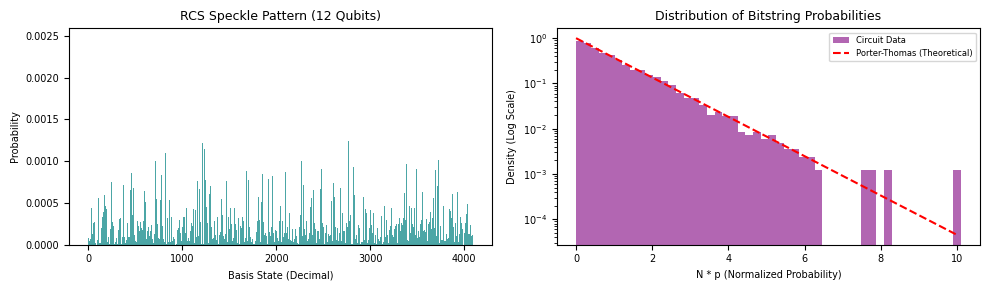

**Thomas-Porter Distribution**: $P(p)=(N-1)(1-p)^{N-2} \approx N e^{-N p}$, where $N=2^n$. $e^{-Np}$ curve = quantum chaos (global scrambling). Reaching $y = e^{-x}$ on log-scale (red dashed line) in histogram, shows successful simulation of global scrambling. **Lieb-Robinson bound**: theoretical limit at which information is scrambled with RCS.  Similar to how OTOCs quantify rate of scrambling (Lyapunov exponent). RCS is designed to exploit the Lieb-Robinson bound to spread information at the maximum possible speed. **Page Scrambling**: RCS is designed to be maximally chaotic (meanwhile Trotterization of physical system can be long time to explore entire Hilbert space. **RCS Speckle pattern**: noise on real hardware leads to flattened speckle = every bitstring equally likely ($1/2^n$). RCS: prove bars still spiky enough for theory. **Scrambling time** $t_S$: for 1D chain architecture in code, to reach Porter-Thomas: need depth that scales linearly with number of qubits ($d∼n$) = light cone from first qubit has reached the last qubit. 2D grid (like Google's Sycamore), depth only needs to scale as $d∼\sqrt{}n$.*

In [ ]:
# @title RCS: Porter-Thomas check → Is circuit design good? (Rotation vs. Interaction - Balancing Local Scrambling + Global Entanglement)
import cirq
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


#print(40*"=")
print("RCS: Experiment zur Zeitentwicklung unter der zeitabhängigen Schrödinger-Gleichung mit zufälligem Hamiltonian")
#print(40*"=")

display(Markdown(r"* **Rotation (Local Scrambling):** Kinetic energy (internal energy of qubits). SU(2) Lie (rotate individual Bloch vectors but cannot create entanglement). **Ideal**: $X^{0.5}, Y^{0.5}, T$. **Real**: `cirq.PhasedXZGate(x_exponent=0.5, axis_phase_exponent=a, z_exponent=0) for a in exponents` which can become any of them by changing phase of axis: $T$ (Phase Gate) is rotation around Z-axis (z_exponent), $Y^{0.5}$ is 90° rotation around y-axis (axis_phase_exponent=0.5), $X^{0.5}$ (Square root of NOT) is 90° rotation around X-axis (axis_phase_exponent=0). On QPU microwave pulse is always same shape ($X^0.5$), but computer changes phase of microwave relative to qubit's clock to make it look like Y or T-gate. **Trotterization** (Ising): use specific X-rotation ($e^{-iθX}$) = one direction, represents Transverse Field trying to flip spins. **RCS**: no specific field but max uncertainty = random rotations in XY plane."))
display(Markdown(r"* **Exchange Interaction (Global Scrambling)**: Potential energy. SU(4).  Real: `cirq.FSimGate(theta=np.pi/2, phi=np.pi/6)` = **θ iSwap** angle (with calibration drift / coherent error because iSwap rarely exactly 90 degrees (exponent 0.5), θ=π/2 is full iSwap) followed by **ϕ CPHASE** angle `cirq.PhasedXZGate` (ZZ-style phase shift during swap). Ideal: `cirq.CZ` = special case of FSim (swap (θ) = 0, phase (ϕ) = π). Google QC is opposite: θ large (natural energy exchange) and ϕ small (accidental phase shift). **Trotterization**: use ZZ interactions ($e^{-iθZZ}$) = Phase-Phase interaction. Qubits don't swap energy; they just change each other's clocks (phases) based on their state. **RCS**: use Exchange interactions like iSwap. There is a physical exchange of the excitation (the 1 state) between qubits. This leads to much faster scrambling."))
display(Markdown(r"* Google OTOC²: no Qubitization, but cycles of random single-qubit gates+fixed two-qubit gates (iSWAP-like, followed by CPHASE, like from RCS."))
display(Markdown(r"* **From Trotterization: $X$-Rotation (Transverse Field $X$:** flip spins (Dynamics) Term $e^{-i X \theta}$ corresponds exactly to an RX gate. **$ZZ$-Interaction $Z_0 Z_1$:** align/anti-align spins (Entanglement). $e^{-i Z \otimes Z \theta}$ operator not natively on QC. Constructed  with sequence: CNOT $\rightarrow$ RZ $\rightarrow$ CNOT."))

def generate_rcs_circuit(qubits, depth):
    circuit = cirq.Circuit()
    gate_set = [cirq.X**0.5, cirq.Y**0.5, cirq.T]

    for d in range(depth):
        # 1. Random single-qubit gates
        for q in qubits:
            gate = np.random.choice(gate_set)
            circuit.append(gate(q))

        # 2. Alternating entangling gates (Brickwork pattern)
        offset = d % 2
        for i in range(offset, len(qubits) - 1, 2):
            circuit.append(cirq.CZ(qubits[i], qubits[i+1]))

    return circuit

print("\n------ Circuit Structure (4 qubits, 4 layers) ------ \n")
n_qubits = 4
qubits = [cirq.LineQubit(i) for i in range(n_qubits)]
depth = 4
circuit = generate_rcs_circuit(qubits, depth)
print(circuit)


# Setup: 12 qubits
n_qubits = 12
qubits = [cirq.LineQubit(i) for i in range(n_qubits)]
depth = 50

# Create and simulate
circuit = generate_rcs_circuit(qubits, depth)
simulator = cirq.Simulator()
result = simulator.simulate(circuit)

# Get the probabilities |psi|^2
probs = np.abs(result.final_state_vector)**2

# --- XEB Fidelity Calculation ---
N = 2**n_qubits
xeb_fidelity = N * np.sum(probs**2) - 1
#print(f"Linear XEB Fidelity: {xeb_fidelity:.4f} ({n_qubits} qubits, {depth} layers) \n")

print(f"\n------ Simulation ({n_qubits} qubits, {depth} layers), Linear XEB Fidelity: {xeb_fidelity:.4f} ------ \n")


# --- Side-by-Side Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
small_size = 7

# Left Plot: Speckle Pattern
ax1.bar(range(2**n_qubits), probs, width=1.0, color='teal', alpha=0.7)
ax1.set_title(f"RCS Speckle Pattern ({n_qubits} Qubits)", fontsize=small_size + 2)
ax1.set_xlabel("Basis State (Decimal)", fontsize=small_size)
ax1.set_ylabel("Probability", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Right Plot: Porter-Thomas Histogram
ax2.hist(N * probs, bins=50, density=True, alpha=0.6, color='purple', label='Circuit Data')
x = np.linspace(0, 10, 100)
ax2.plot(x, np.exp(-x), 'r--', label='Porter-Thomas (Theoretical)')
ax2.set_yscale('log')
ax2.set_title("Distribution of Bitstring Probabilities", fontsize=small_size + 2)
ax2.set_xlabel("N * p (Normalized Probability)", fontsize=small_size)
ax2.set_ylabel("Density (Log Scale)", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)
ax2.legend(fontsize=small_size - 1)

plt.tight_layout()
plt.show()

display(Markdown(r"**Thomas-Porter Distribution**: $P(p)=(N-1)(1-p)^{N-2} \approx N e^{-N p}$, where $N=2^n$. $e^{-Np}$ curve = quantum chaos (global scrambling). Reaching $y = e^{-x}$ on log-scale (red dashed line) in histogram, shows successful simulation of global scrambling. **Lieb-Robinson bound**: theoretical limit at which information is scrambled with RCS.  Similar to how OTOCs quantify rate of scrambling (Lyapunov exponent). RCS is designed to exploit the Lieb-Robinson bound to spread information at the maximum possible speed. **Page Scrambling**: RCS is designed to be maximally chaotic (meanwhile Trotterization of physical system can be long time to explore entire Hilbert space. **RCS Speckle pattern**: noise on real hardware leads to flattened speckle = every bitstring equally likely ($1/2^n$). RCS: prove bars still spiky enough for theory. **Scrambling time** $t_S$: for 1D chain architecture in code, to reach Porter-Thomas: need depth that scales linearly with number of qubits ($d∼n$) = light cone from first qubit has reached the last qubit. 2D grid (like Google's Sycamore), depth only needs to scale as $d∼\sqrt{}n$.*"))


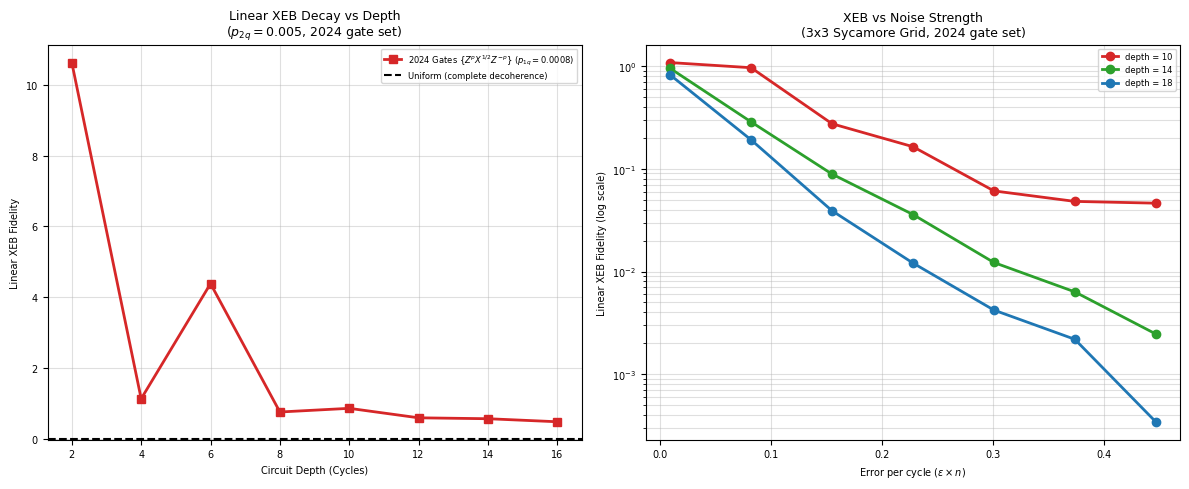

* 'build_circuits_2024' returns two circuits from same random gate sequence: ideal and noisy simulation

* Ideal circuit is simulated with Simulator() → just gates, no noise channels, gives pure state vector sv (what perfect quantum computer would produce)

* Noisy circuit is simulated with DensityMatrixSimulator() → same gates, but with cirq.depolarize(...), gives density matrix rho (what real, noisy QC produces)

* XEB computed by comparing them: ' xeb = dim * sum(|sv|² · diag(rho)) - 1'. Masures how much the noisy output correlates with the ideal output probabilities.


------ Print deepest circuit at highest noise ------ 

                                        ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌────────────────────────────────────┐                                          ┌──────────────────────────────────────────────────────┐                                          ┌──────────────────────────────────────────────────────┐                                          ┌──────────────────────────────────────────────────────┐                                          ┌────────────────────────────────────┐            

In [ ]:
# @title RCS: XEB vs depth/noise → How does noise corrupt it?
import cirq
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, Markdown

# Based on 'Phase transitions in random circuit sampling' https://www.nature.com/articles/s41586-024-07998-6

# --- setup ---
n_rows, n_cols = 3, 3
qubits = [cirq.GridQubit(i, j) for i in range(n_rows) for j in range(n_cols)]
n_qubits = len(qubits)
dim = 2 ** n_qubits

SYC_GATE = cirq.FSimGate(theta=np.pi / 2, phi=np.pi / 6)
p_values = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]


def get_2q_layer():
    edges = []
    for i in range(n_rows):
        for j in range(n_cols):
            if i < n_rows - 1:
                edges.append((cirq.GridQubit(i, j), cirq.GridQubit(i + 1, j)))
            if j < n_cols - 1:
                edges.append((cirq.GridQubit(i, j), cirq.GridQubit(i, j + 1)))
    random.shuffle(edges)
    layer, used = [], set()
    for q1, q2 in edges:
        if q1 not in used and q2 not in used:
            layer.append(SYC_GATE.on(q1, q2))
            used.update([q1, q2])
    return layer


def build_circuits_2024(depth, noise_1q, noise_2q):
    """2024 gate set: PhasedXPowGate as a single primitive
    (Z^p X^{1/2} Z^{-p}, with virtual Z done in software)."""
    ideal = cirq.Circuit()
    noisy = cirq.Circuit()
    for _ in range(depth):
        ones = {q: cirq.PhasedXPowGate(phase_exponent=random.choice(p_values),
                                       exponent=0.5)
                for q in qubits}
        layer_1q = cirq.Moment(ones[q].on(q) for q in qubits)
        ideal.append(layer_1q)
        noisy.append(layer_1q)
        if noise_1q > 0:
            noisy.append(cirq.Moment(
                cirq.depolarize(noise_1q).on(q) for q in qubits
            ))

        twoq = get_2q_layer()
        ideal.append(cirq.Moment(twoq))
        noisy.append(cirq.Moment(twoq))
        if noise_2q > 0:
            noise_ops = []
            for op in twoq:
                for q in op.qubits:
                    noise_ops.append(cirq.depolarize(noise_2q).on(q))
            noisy.append(cirq.Moment(noise_ops))
    return ideal, noisy


ideal_sim = cirq.Simulator()
noisy_sim = cirq.DensityMatrixSimulator()
trials = 3

# ======================================================================
# Experiment 1: XEB decay vs depth at fixed hardware quality
# ======================================================================
depths_decay   = [2, 4, 6, 8, 10, 12, 14, 16]
noise_1q_2024  = 0.0008
noise_2q_fixed = 0.005

xeb_2024 = np.zeros(len(depths_decay))

#print("✅ Experiment 1: XEB vs depth...")
for idx, d in enumerate(depths_decay):
    x24 = 0.0
    for _ in range(trials):
        c_i, c_n = build_circuits_2024(d, noise_1q_2024, noise_2q_fixed)
        sv  = ideal_sim.simulate(c_i).final_state_vector
        rho = noisy_sim.simulate(c_n).final_density_matrix
        x24 += dim * np.sum(np.abs(sv) ** 2 * np.real(np.diag(rho))) - 1
    xeb_2024[idx] = x24 / trials
    #print(f"  Depth {d} done.")

# ======================================================================
# Experiment 2: XEB vs noise strength at fixed depths
# ======================================================================
base_1q = 0.0008
base_2q = 0.005
scales = np.linspace(0.25, 12.0, 7)
depths_sweep = [10, 14, 18]

#  the noise sweep at depth 18 is the heaviest single chunk.
# If you want a faster smoke test, drop trials to 2 and shorten scales to np.linspace(0.25, 12.0, 7).

results = {d: np.zeros(len(scales)) for d in depths_sweep}

#print("✅ Experiment 2: noise sweep...")
for d in depths_sweep:
    for j, s in enumerate(scales):
        p_1q = base_1q * s
        p_2q = base_2q * s
        x = 0.0
        for _ in range(trials):
            c_ideal, c_noisy = build_circuits_2024(d, p_1q, p_2q)
            sv  = ideal_sim.simulate(c_ideal).final_state_vector
            rho = noisy_sim.simulate(c_noisy).final_density_matrix
            x += dim * np.sum(np.abs(sv) ** 2 * np.real(np.diag(rho))) - 1
        results[d][j] = x / trials
    #print(f"  Depth {d} done.")

errors_per_cycle = scales * (9 * base_1q + 6 * base_2q)

# ======================================================================
# Side-by-side plot
# ======================================================================

# --- Side-by-Side Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
small_size = 7

# Left: XEB vs depth
ax1.plot(depths_decay, xeb_2024, marker='s',
         label=fr'2024 Gates $\{{Z^p X^{{1/2}} Z^{{-p}}\}}$ '
               fr'($p_{{1q}}={noise_1q_2024}$)',
         color='#d62728', linewidth=2)
ax1.axhline(0, color='black', linestyle='--',
            label='Uniform (complete decoherence)')
ax1.set_title(f'Linear XEB Decay vs Depth\n'
              f'($p_{{2q}}={noise_2q_fixed}$, 2024 gate set)', fontsize=small_size + 2)
ax1.set_xlabel('Circuit Depth (Cycles)', fontsize=small_size)
ax1.set_ylabel('Linear XEB Fidelity', fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)
ax1.legend(fontsize=small_size - 1)
ax1.grid(True, alpha=0.4)

# Right: XEB vs noise strength
colors = ['#d62728', '#2ca02c', '#1f77b4']
for d, color in zip(depths_sweep, colors):
    y = results[d]
    mask = y > 0  # only positive values on log axis
    ax2.semilogy(errors_per_cycle[mask], y[mask],
                 marker='o', label=f'depth = {d}', color=color, linewidth=2)

ax2.set_xlabel(r'Error per cycle ($\epsilon \times n$)', fontsize=small_size)
ax2.set_ylabel('Linear XEB Fidelity (log scale)', fontsize=small_size)
ax2.set_title('XEB vs Noise Strength\n(3x3 Sycamore Grid, 2024 gate set)', fontsize=small_size + 2)
ax2.tick_params(axis='both', labelsize=small_size)
ax2.legend(fontsize=small_size - 1)
ax2.grid(True, alpha=0.4, which='both')

plt.tight_layout()
plt.show()

from IPython.display import display, Markdown
display(Markdown(r"* 'build_circuits_2024' returns two circuits from same random gate sequence: ideal and noisy simulation"))
display(Markdown(r"* Ideal circuit is simulated with Simulator() → just gates, no noise channels, gives pure state vector sv (what perfect quantum computer would produce)"))
display(Markdown(r"* Noisy circuit is simulated with DensityMatrixSimulator() → same gates, but with cirq.depolarize(...), gives density matrix rho (what real, noisy QC produces)"))
display(Markdown(r"* XEB computed by comparing them: ' xeb = dim * sum(|sv|² · diag(rho)) - 1'. Masures how much the noisy output correlates with the ideal output probabilities."))
#display(Markdown(r"* Plot (XEB vs depth) and plot (XEB vs noise strength) show same metric, just sweep different axes. Every dot on both plots required running both simulations."))

print("\n------ Print deepest circuit at highest noise ------ \n")
# that's the regime where XEB has collapsed, and you can see why (lots of depolarize channels piling up):
d = max(depths_sweep)        # 18
s = scales[-1]               # 12.0, the strongest noise
p_1q = base_1q * s
p_2q = base_2q * s
ideal, noisy = build_circuits_2024(d, p_1q, p_2q)
print(noisy)

#from cirq.contrib.svg import SVGCircuit
#SVGCircuit(noisy)

OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)


* Simple chaotic Hamiltonian is mixed-field Ising: $H = \sum Z_i Z_{i+1} + h_x \sum X_i + h_z \sum Z_i$. Longitudinal field $h_z$ breaks integrability and turns it chaotic.

* **OTOC** messen das Scrambling von Information. Wenn du einen Operator W(t) zu einer Zeit t hast und einen Operator V(0) zum Zeitpunkt 0, misst der OTOC $ \langle W^\dagger(t) V^\dagger(0) W(t) V(0) \rangle $, **wie stark diese Operatoren nach der Zeit t nicht mehr kommutieren**. QM Äquivalent zum Schmetterlingseffekt.

* **OTOC** $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ is metric to quantify quantum chaos and rate of scrambling (quantum Lyapunov exponent). **Operator Spreading:** local operator $\hat{V}$ (Pauli gate) evolves under chaotic Hamiltonian into non-local operator $\hat{V}(t) = e^{iHt}\hat{V}e^{-iHt}$ (Eigenstate Thermalization)

* OTOC is calculated via sequence: ***Forward Evolution***: Apply Qubitization Walk $n$ times (simulating time $+t$). ***Perturbation***: Apply Butterfly operator $\hat{V}$ ($X$ gate). ***Backward Evolution***: Apply inverse Qubitization Walk $n$ times (simulating time $-t$). ***Measurement***: Apply probe operator $\hat{W}$ and check correlation.

...

* **Heisenberg Evolution** $\hat{W}(t) = e^{iHt} \hat{W}(0) e^{-iHt}$ to calculate $\hat{W}(t)$, where $e^{-iHt}$ is solution to Schrödinger. Without Schrödinger, no $\hat{W}(t)$ and no OTOC.

* **Loschmidt Echo**: measure OTOC on QC: 1. Evolve forward ($e^{-iHt}$) 2. Perturbation ($\hat{V}$) 3. Evolve backward ($e^{+iHt}$ - time reversal) 4. Measure overlap

*An OTOC is defined as $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$. The core concept here is Operator Spreading. We want to see how a local operator $\hat{W}$ at time $0$ evolves into a complex, non-local operator $\hat{W}(t) = \hat{U}^\dagger(t) \hat{W}(0) \hat{U}(t)$ at time $t$. We are asking: How much does the future measurement of $W$ depend on a past perturbation $V$? - If the system is chaotic, $\hat{W}(t)$ spreads across the system and eventually fails to commute with $\hat{V}(0)$, causing the OTOC to grow.*

* **Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole.

* **Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:

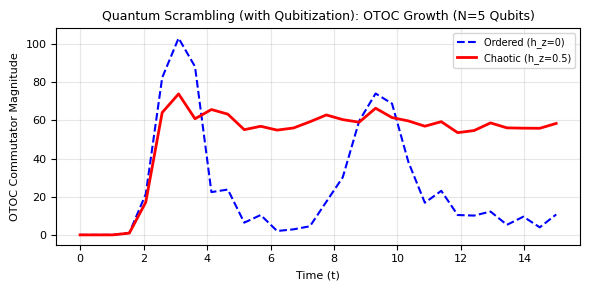

In [ ]:
# @title OTOC: On Chaotic Hamiltonian (Mixed-field Ising model)

# OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)
# ==========================================
# OTOC (Linear Algebra Implementation)
# ==========================================

from scipy.linalg import norm
from IPython.display import display, Markdown

print(40*"=")
print("OTOC (Quantum Dynamics, Quantum Chaos and Scrambling)")
print(40*"=")

display(Markdown(r"* Simple chaotic Hamiltonian is mixed-field Ising: $H = \sum Z_i Z_{i+1} + h_x \sum X_i + h_z \sum Z_i$. Longitudinal field $h_z$ breaks integrability and turns it chaotic."))
display(Markdown(r"* **OTOC** messen das Scrambling von Information. Wenn du einen Operator W(t) zu einer Zeit t hast und einen Operator V(0) zum Zeitpunkt 0, misst der OTOC $ \langle W^\dagger(t) V^\dagger(0) W(t) V(0) \rangle $, **wie stark diese Operatoren nach der Zeit t nicht mehr kommutieren**. QM Äquivalent zum Schmetterlingseffekt."))
display(Markdown(r"* **OTOC** $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ is metric to quantify quantum chaos and rate of scrambling (quantum Lyapunov exponent). **Operator Spreading:** local operator $\hat{V}$ (Pauli gate) evolves under chaotic Hamiltonian into non-local operator $\hat{V}(t) = e^{iHt}\hat{V}e^{-iHt}$ (Eigenstate Thermalization)"))
display(Markdown(r"* OTOC is calculated via sequence: ***Forward Evolution***: Apply Qubitization Walk $n$ times (simulating time $+t$). ***Perturbation***: Apply Butterfly operator $\hat{V}$ ($X$ gate). ***Backward Evolution***: Apply inverse Qubitization Walk $n$ times (simulating time $-t$). ***Measurement***: Apply probe operator $\hat{W}$ and check correlation."))
display(Markdown(r"* **Four-Point Function:** evolve forward and backward in time: $W(t) = e^{iHt} W(0) e^{-iHt}$. Schrödinger (moving states) $\rightarrow$ Heisenberg (moving operators)"))
display(Markdown(r"* **Time-Dependent Schrödinger** $|\Psi(t)\rangle = e^{-iHt} |\Psi(0)\rangle$ tells how state moves. OTOC describes if chaotic or ordered. Time-Dependent part hidden in $\hat{W}(t)$."))
display(Markdown(r"* **Heisenberg Evolution** $\hat{W}(t) = e^{iHt} \hat{W}(0) e^{-iHt}$ to calculate $\hat{W}(t)$, where $e^{-iHt}$ is solution to Schrödinger. Without Schrödinger, no $\hat{W}(t)$ and no OTOC."))
display(Markdown(r"* **Loschmidt Echo**: measure OTOC on QC: 1. Evolve forward ($e^{-iHt}$) 2. Perturbation ($\hat{V}$) 3. Evolve backward ($e^{+iHt}$ - time reversal) 4. Measure overlap"))
display(Markdown(r"*An OTOC is defined as $C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$. The core concept here is Operator Spreading. We want to see how a local operator $\hat{W}$ at time $0$ evolves into a complex, non-local operator $\hat{W}(t) = \hat{U}^\dagger(t) \hat{W}(0) \hat{U}(t)$ at time $t$. We are asking: How much does the future measurement of $W$ depend on a past perturbation $V$? - If the system is chaotic, $\hat{W}(t)$ spreads across the system and eventually fails to commute with $\hat{V}(0)$, causing the OTOC to grow.*"))
display(Markdown(r"* **Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole."))
display(Markdown(r"* **Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:"))

def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_curve(num_qubits, h_x, h_z, time_points):
    """
    Calculates the OTOC C(t) = || [W(t), V] ||^2
    V = X on Qubit 0 (The Perturbation)
    W = Z on Qubit N-1 (The Probe)
    """
    qubits = cirq.LineQubit.range(num_qubits)
    otoc_values = []

    # Define Operators V (at t=0) and W (at t=0)
    # We build them as full matrices (2^N x 2^N)

    # V = X_0 (Tensor product: X I I I...)
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    # W = Z_last (Tensor product: ...I I I Z)
    op_list_W = [np.eye(2)] * num_qubits
    op_list_W[-1] = np.array([[1, 0], [0, -1]]) # Z
    W = op_list_W[-1]
    for i in range(num_qubits-2, -1, -1):
        W = np.kron(op_list_W[i], W)

    #print(f"Simulating: h_x={h_x}, h_z={h_z}...")

    for t in time_points:
        if t == 0:
            otoc_values.append(0)
            continue

        # 1. Get Time Evolution Operator U(t)
        U = get_unitary_from_circuit(qubits, t, h_x, h_z)
        U_dag = U.conj().T

        # 2. Evolve W forward in time (Heisenberg Picture)
        # W(t) = U^dagger * W * U
        W_t = U_dag @ W @ U

        # 3. Calculate Commutator C = [W(t), V] = W(t)V - VW(t)
        commutator = W_t @ V - V @ W_t

        # 4. Measure "Size" of commutator (Frobenius Norm)
        # This tells us how non-commutative they have become
        c_val = np.linalg.norm(commutator) ** 2
        otoc_values.append(c_val)

    return otoc_values

# --- Simulation Setup ---
# A simple chaotic Hamiltonian is the mixed-field Ising model:

n_qubits = 5  # Small enough for matrix multiplication
times = np.linspace(0, 15.0, 30)

# Scenario 1: Ordered / Integrable (Ising Model)
# No longitudinal field (h_z = 0)
otoc_ordered = calculate_otoc_curve(n_qubits, h_x=1.0, h_z=0.0, time_points=times)

# Scenario 2: Chaotic (Non-Integrable)
# We add a longitudinal field (h_z = 0.5) to break symmetry
otoc_chaotic = calculate_otoc_curve(n_qubits, h_x=1.0, h_z=0.5, time_points=times)

# --- Plotting ---
plt.figure(figsize=(6, 3))
small_size = 8 # font size
plt.plot(times, otoc_ordered, label='Ordered (h_z=0)', color='blue', linestyle='--')
plt.plot(times, otoc_chaotic, label='Chaotic (h_z=0.5)', color='red', linewidth=2)
plt.title(f'Quantum Scrambling (with Qubitization): OTOC Growth (N={n_qubits} Qubits)', fontsize=small_size + 1)
plt.xlabel('Time (t)', fontsize=small_size)
plt.ylabel('OTOC Commutator Magnitude', fontsize=small_size)
plt.legend(fontsize=small_size - 1) # fint size on legend slightly smaller
plt.tick_params(axis='both', labelsize=small_size)

plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures labels don't get cut off at smaller sizes
plt.show()

* **MSS bound (Maldacena-Shenker-Stanford Schranke)**: $\lambda_L \leq 2\pi/\beta$. Vermutung, dass Schwarze Löcher die schnellsten Scrambler der Natur sind. Ties scrambling to thermodynamics and black holes (saturate bound). Connects OTOCs to JT gravity, SYK, + Hayden-Preskill protocol.

* **Quantum Butterfly Effect**: Calculates OTOC between first qubit and other qubits. Proof how information spreads physically (light cone of scrambling in real).

* **Lieb-Robinson Light Cone (Bound)** (diagonal V-shape): information has speed limit **Butterfly Velocity** $v_B$ (slope of diagonal line) as it travels down chain

* **Lieb-Robinson velocity** sets the universal speed limit on how fast information can propagate in a local quantum system. The speed limit shows up in three places: it's the slope of the OTOC light cone (the butterfly velocity), it's why RCS depth scales linearly with $n$ in 1D and as $\sqrt{n}$ in 2D, and it's the operator-spreading velocity in random unitary circuits.

* **Porter-Thomas distribution** $P(p) \approx N e^{-Np}$ (with $N = 2^n$) is the bitstring probabilities histogram in RCS. It is the fingerprint of a **Haar-random unitary**. The depth needed to **reach Porter-Thomas — the scrambling time** — is set by the circuit geometry: $d \sim n$ for a 1D chain, $d \sim \sqrt{n}$ for a 2D grid like Sycamore. This is the light cone from the **Lieb-Robinson bound** reaching across the device.

* **Page scrambling time** is when a system has thermalized so thoroughly that most qubits need to be measured to recover any local information. RCS is designed to push system to Page scrambling as fast as possible → is why it uses Haar-random gates rather than evolution under a specific Hamiltonian.

* **Poincare Recurrence** (Left) with Ballistic Echoes. Information remains particle-like and bounces back coherently to original state.

* **Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole.

* **Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:

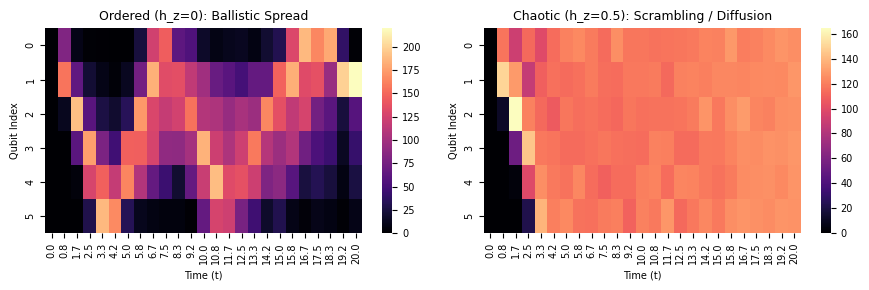

*$C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ quantifies rate of scrambling. $\hat{V}(0)$: Butterfly (small local perturbation at start). $\hat{W}(t)$ measurement later in time. At $t=0$, $W$ and $V$ commute (are on different qubits). Commutator is 0. As time evolves, $\hat{W}(t)$ grows spatially (scrambling). Eventually, $\hat{W}(t)$ hits the qubit where $\hat{V}$ sits. They no longer commute. Commutator grows, and $C(t)$ deviates from zero. Result: rate at which OTOC grows is Lyapunov Exponent ($\lambda$), the speed limit of chaos.*

In [ ]:
# @title OTOC: Light Cone of Scrambling (OTOC for all qubits over time. Ordered vs Chaotic)

display(Markdown(r"* **MSS bound (Maldacena-Shenker-Stanford Schranke)**: $\lambda_L \leq 2\pi/\beta$. Vermutung, dass Schwarze Löcher die schnellsten Scrambler der Natur sind. Ties scrambling to thermodynamics and black holes (saturate bound). Connects OTOCs to JT gravity, SYK, + Hayden-Preskill protocol."))
display(Markdown(r"* **Quantum Butterfly Effect**: Calculates OTOC between first qubit and other qubits. Proof how information spreads physically (light cone of scrambling in real)."))
display(Markdown(r"* **Lieb-Robinson Light Cone (Bound)** (diagonal V-shape): information has speed limit **Butterfly Velocity** $v_B$ (slope of diagonal line) as it travels down chain"))
display(Markdown(r"* **Lieb-Robinson velocity** sets the universal speed limit on how fast information can propagate in a local quantum system. The speed limit shows up in three places: it's the slope of the OTOC light cone (the butterfly velocity), it's why RCS depth scales linearly with $n$ in 1D and as $\sqrt{n}$ in 2D, and it's the operator-spreading velocity in random unitary circuits."))
display(Markdown(r"* **Porter-Thomas distribution** $P(p) \approx N e^{-Np}$ (with $N = 2^n$) is the bitstring probabilities histogram in RCS. It is the fingerprint of a **Haar-random unitary**. The depth needed to **reach Porter-Thomas — the scrambling time** — is set by the circuit geometry: $d \sim n$ for a 1D chain, $d \sim \sqrt{n}$ for a 2D grid like Sycamore. This is the light cone from the **Lieb-Robinson bound** reaching across the device."))
display(Markdown(r"* **Page scrambling time** is when a system has thermalized so thoroughly that most qubits need to be measured to recover any local information. RCS is designed to push system to Page scrambling as fast as possible → is why it uses Haar-random gates rather than evolution under a specific Hamiltonian."))
display(Markdown(r"* **Poincare Recurrence** (Left) with Ballistic Echoes. Information remains particle-like and bounces back coherently to original state."))
display(Markdown(r"* **Quantum Chaos** (Right). Information scrambles (thermalizes). By t=20, system is perfect model for how information is hidden in Black Hole."))
display(Markdown(r"* **Interaction strength $J$** increase makes slope steeper (information moves faster) and quantum chaos $h_z$ grows faster. Light Cone of Information Scrambling:"))

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()

display(Markdown(r"*$C(t) = \langle [\hat{W}(t), \hat{V}(0)]^\dagger [\hat{W}(t), \hat{V}(0)] \rangle$ quantifies rate of scrambling. $\hat{V}(0)$: Butterfly (small local perturbation at start). $\hat{W}(t)$ measurement later in time. At $t=0$, $W$ and $V$ commute (are on different qubits). Commutator is 0. As time evolves, $\hat{W}(t)$ grows spatially (scrambling). Eventually, $\hat{W}(t)$ hits the qubit where $\hat{V}$ sits. They no longer commute. Commutator grows, and $C(t)$ deviates from zero. Result: rate at which OTOC grows is Lyapunov Exponent ($\lambda$), the speed limit of chaos.*"))

<font color="blue">**Quanten-Chaos-Konzepte**

1. Fast-Scrambling & Operator-Wachstum

* **Scrambling-Zeit:** Logarithmisch in der Systemgröße — schwarze Löcher sind die schnellsten Scrambler des Universums.
$$t_* \sim \frac{1}{\lambda_L}\ln N$$

* **Operatorgröße $n(t)$:** Mittlere Anzahl nicht-trivialer Pauli-Faktoren in der Pauli-String-Zerlegung von $W(t)$; wächst exponentiell bis zur Sättigung.
$$\frac{dn}{dt} = \lambda_L\, n(t) \implies n(t) \sim e^{\lambda_L t}$$

* **Operator-Größen-Verteilung:** Wahrscheinlichkeit, dass $W(t)$ Größe $n$ hat; $C(t)$ ist ihr erstes Moment.
$$P(n,t) = \!\!\sum_{I:\,n(I)=n}\!\! |c_I(t)|^2, \qquad C(t) \propto \frac{\langle n(t)\rangle}{N}$$

* **Butterfly-Geschwindigkeit:** Räumliche Ausbreitungsrate der Operatorfront — gibt die Steigung des Lichtkegels im OTOC.
$$C(t,x) \sim \frac{1}{N}\,e^{\lambda_L(t - x/v_B)}$$

2. Krylov-Komplexität & Lanczos

* **Liouvillian:** Superoperator, der Heisenberg-Evolution erzeugt; seine Tridiagonalisierung definiert die Krylov-Basis.
$$\mathcal{L} = [H,\cdot], \qquad O(t) = e^{i\mathcal{L}t}O$$

* **Lanczos-Rekursion:** Tridiagonale Form von $\mathcal{L}$ auf der Krylov-Kette; $b_n$ = Hopping-Amplituden zwischen Krylov-Plätzen.
$$\mathcal{L}|O_n) = b_{n+1}|O_{n+1}) + b_n|O_{n-1})$$

* **Krylov-Komplexität:** Mittlere Position auf der Krylov-Kette; misst algebraische Tiefe der Operator-Evolution.
$$K(t) = \sum_n n\,|\varphi_n(t)|^2$$

* **Universal Operator Growth Hypothesis (UOGH):** Bei nicht-integrablen Systemen wachsen die $b_n$ linear, mit Steigung durch KMS-Analytizität beschränkt.
$$b_n = \alpha\,n + \gamma + o(1), \qquad \alpha \leq \pi/\beta$$

* **Wachstumsregimes:**
$$b_n \to \text{const} \Rightarrow K \sim t \quad (\text{integrabel})$$
$$b_n \sim \sqrt{n} \Rightarrow K \sim t^2 \quad (\text{frei})$$
$$b_n \sim \alpha n \Rightarrow K \sim e^{2\alpha t} \quad (\text{chaotisch})$$

3. MSS-Schranke & KMS-Analytizität

* **OTOC (quadrierter Kommutator):** Misst Operator-Spreading via Nicht-Kommutativität zur Zeit $t$.
$$C(t) = \langle[W(t),V]^\dagger[W(t),V]\rangle_\beta \simeq \frac{2K}{N}e^{\lambda_L t}$$

* **MSS-Schranke:** Universelle Obergrenze für die Quanten-Lyapunov-Rate; gesättigt von Schwarzen Löchern und SYK.
$$\lambda_L \leq \frac{2\pi}{\beta} = \frac{2\pi k_B T}{\hbar}$$

* **KMS-Bedingung:** Verknüpft thermische Korrelatoren mit imaginärer Zeit — Quelle der Analytizität im Streifen $0 \leq \mathrm{Im}(t) \leq \beta$.
$$\langle A(t)B(0)\rangle_\beta = \langle B(0)A(t+i\beta)\rangle_\beta$$

* **Regularisierter OTOC:** $\rho^{1/4}$ symmetrisch verteilt; der MSS-Beweis lebt auf dieser Funktion.
$$F(t) = \mathrm{Tr}\!\left[\rho^{1/4}W(t)\rho^{1/4}V\rho^{1/4}W(t)\rho^{1/4}V\right]$$

* **Stack:** Algebraisches Prinzip → algorithmische Schranken.
$$\text{KMS-Analytizität} \Rightarrow \alpha \leq \pi/\beta \Rightarrow \lambda_L \leq 2\alpha \leq 2\pi/\beta$$

4. Eigenstate Thermalization Hypothesis (ETH)

* **ETH-Ansatz (Srednicki):** Matrixelemente lokaler Operatoren in Energieeigenzuständen — diagonaler Teil thermisch, off-diagonal exponentiell unterdrückt.
$$A_{mn} = \mathcal{A}(\bar E)\delta_{mn} + e^{-S(\bar E)/2}f_A(\bar E,\omega)R_{mn}$$

* **Kerneinsicht:** Ein einzelner Energieeigenzustand verhält sich lokal bereits wie ein thermisches Ensemble; das System thermalisiert *lokal*, bleibt aber global rein.

* **Klassifikation:**
$$\text{Chaotisch: ETH erfüllt} \,|\, \text{Integrabel: GGE} \,|\, \text{MBL: keine Thermalisierung}$$

* **Zeitliche Hierarchie:**
$$t_{\text{therm}} \sim \mathcal{O}(1) \,<\, t_*^{\text{scrambling}} \sim \ln N \,<\, t_K^{\text{Krylov}} \sim e^S$$

5. Yoshida-Kitaev-Decoder

* **Hayden-Preskill (2007):** Information, die in einen Scrambler fällt, kann aus früher emittierter Strahlung in Zeit $\mathcal{O}(\ln N)$ rekonstruiert werden — falls man die Dynamik kennt.

* **YK-Decoder (2017):** Probabilistisches Protokoll mit zwei Kopien $U$ und $U^*$, das Scrambling als Teleportations-Kanal nutzt.
$$\text{Fidelity} \propto \langle W(t)^\dagger V^\dagger W(t) V\rangle_\beta \quad (\text{= OTOC})$$

* **Paradoxe Konsequenz:** Decoder funktioniert *gerade dann*, wenn das System maximal scrambelt (OTOC → 0); Chaos = Übertragungs-Ressource.

6. Random Unitary Circuits (RUCs)

* **Definition:** Brickwork aus Haar-zufälligen 2-Qubit-Gates; kein Hamiltonian, maximal chaotisch by construction.

* **Operator-Spreading (Nahum-Vijay-Haah 2018):** KPZ-Universalitätsklasse — ballistische Front mit diffusiver Verbreiterung.
$$\langle x_{\text{front}}\rangle = v_B t, \qquad \sigma(t) \sim t^{1/3}$$

* **Verschränkungs-Wachstum:** Linear in $t$ mit Geschwindigkeit $v_E \leq v_B$ (Mezei-Stanford-Schranke).
$$S(t) = v_E\, t + \mathcal{O}(t^{1/3})$$

* **Dual-Unitary:** Gates sowohl in Raum- als auch Zeitrichtung unitär; OTOC verschwindet *exakt* außerhalb des Lichtkegels — deterministisch lösbar, $v_B$ saturiert Lieb-Robinson.

* **Messungs-induzierter Phasenübergang (MIPT):** Bei Mess-Rate $p$ pro Site: Volumengesetz für $p < p_c$, Flächengesetz für $p > p_c$.
$$S(p) = \begin{cases} \propto L & p < p_c \\ \mathcal{O}(1) & p > p_c \end{cases}$$

7. Scrambling als algorithmische Schranke

* **Lieb-Robinson:** Information-Geschwindigkeitslimit in lokalen Systemen; setzt Tiefe-Untergrenze für globale Entanglement-Erzeugung.
$$\|[A(t),B]\| \leq C\,e^{-\mu(d - v_{LR}t)}$$

* **Tiefe-Skalierung für globale Verschränkung:**
$$d_{\min} \sim \begin{cases} n & \text{1D} \\ \sqrt{n} & \text{2D} \\ \log n & \text{all-to-all} \end{cases}$$

* **Hamiltonian-Simulation:** Lieb-Robinson saturiert von Haah-Hastings-Kothari-Low 2018 — Gate-Komplexität ist *Scrambling-limitiert*.
$$\text{Gates} = \mathcal{O}(nt\cdot\mathrm{polylog}(1/\epsilon))$$

* **Barren Plateaus (McClean et al. 2018):** Volles Scrambling → exponentiell flache Optimierungs-Landschaft, VQAs untrainierbar.
$$\mathrm{Var}[\partial_\theta E] \sim 2^{-n}$$

* **Vikram-Shou-Galitski-Schranke:** Untere Schranke für Scrambling-Zeit aus Entropie.
$$t_s \gtrsim \log S$$

8. Quick-Lookup-Tabelle

| Größe | Symbol | Bound | Wo |
|---|---|---|---|
| Lyapunov | $\lambda_L$ | $\leq 2\pi/\beta$ | OTOC |
| Lanczos-Steigung | $\alpha$ | $\leq \pi/\beta$ | Krylov |
| Butterfly | $v_B$ | $\leq v_{LR}$ | RUC, OTOC |
| Modulares Chaos | $\kappa$ | $\leq 2\pi$ | de Boer-Lamprou |
| Scrambling-Zeit | $t_*$ | $\geq \frac{\beta}{2\pi}\ln N$ | Fast-Scrambling |
| VQA-Gradient | $\mathrm{Var}[\partial E]$ | $\sim 2^{-n}$ | Barren Plateau |

Operatoralgebra: Tomita-Takesaki (modular Fluss, KMS), Crossed Products, Modular Chaos und Lyapunov-Schranken. Cohomology: Hochschild- und zyklische Kohomologie, K-Theorie, Spektrale Tripel und Indextheorie, Charakteristische Klassen

> Quantum Chaos Classification: Scrambling time of quantum system bounded by cohomology of its operator algebra (under modular flow)

###### ---- IonQ Quantum Computing ----

In [ ]:
# IonQ libraries
!pip install cirq-ionq -q
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits
import json
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files
from collections import Counter
import matplotlib.pyplot as plt
import cirq_ionq.ionq_exceptions as ionq_exceptions
from IPython.display import display, Markdown

In [ ]:
# Connect to IonQ Service and Secret Manager for Token
from google.colab import userdata
api_token = userdata.get('ionq-quantum')
service = cirq_ionq.Service(api_key=api_token)
print("✅ Connection to IonQ successful")

# Check Available Backends (Simulators and QPUs)
print("\n✅ List of all backends (https://cloud.ionq.com/backends/qpus)")
headers = {"Authorization": f"apiKey {'ionq-quantum'}"}
r = requests.get("https://api.ionq.co/v0.3/backends", headers=headers)
if r.status_code == 200:
    available = [b for b in r.json() if b['status'].upper() == 'AVAILABLE']
    for i, b in enumerate(available, 1):
    #for i, b in enumerate(r.json(), 1): # to print all backends
        qt = b.get('average_queue_time', 0)
        print(f"\n{i}. {b['backend'].upper()}\n └── Type: {'QPU' if 'qpu' in b['backend'] else 'Simulator'}\n └── Status: {b['status'].upper()}\n └── Qubits: {b['qubits']}\n └── Average Queue Time: {f'{qt/3600:.1f} hours' if qt > 3600 else f'{qt/60:.1f} minutes' if qt > 60 else f'{qt} seconds'}" + (''.join([f"\n └── Available Noise Models: {', '.join(b['noise_models'])}" if 'noise_models' in b else "", f"\n └── Characterization: Available" if 'characterization_url' in b else "", f"\n └── DEGRADED SERVICE" if b.get('degraded', False) else ""])))
else: print(f"Backend check failed: {r.status_code}\nError details: {r.text}")


BACKEND = "qpu.forte-1" # forte-1, forte-enterprise-1, aria-1
print(f"\n✅ Selected backend: {BACKEND}")

# https://quantumai.google/cirq/hardware/ionq/calibrations - Error: Insufficient Scope
#calibration = service.get_current_calibration()
#print(calibration.fidelities())
#print(calibration.timings())

✅ Connection to IonQ successful

✅ List of all backends (https://cloud.ionq.com/backends/qpus)

1. QPU.FORTE-1
 └── Type: QPU
 └── Status: AVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 3222.9 hours
 └── Characterization: Available

2. SIMULATOR
 └── Type: Simulator
 └── Status: AVAILABLE
 └── Qubits: 29
 └── Average Queue Time: 0 seconds
 └── Available Noise Models: aria-1, forte-1, forte-enterprise-1, ideal

3. QPU.FORTE-ENTERPRISE-1
 └── Type: QPU
 └── Status: AVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 1908.5 hours
 └── Characterization: Available

✅ Selected backend: qpu.forte-1


In [ ]:
# IonQ Circuit and Transpilation

print("\n✅ Quantum Circuit and Transpilation")
display(Markdown(r"Two-Qubit maximally entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) preparation $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ with each outcomes $|00\rangle$ and $|11\rangle$ at 50% probability."))
q0, q1 = cirq.LineQubit.range(2)
circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1, key='x'))
print(circuit)


✅ Quantum Circuit and Transpilation


Two-Qubit maximally entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) preparation $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ with each outcomes $|00\rangle$ and $|11\rangle$ at 50% probability.

0: ───H───@───M('x')───
          │   │
1: ───────X───M────────



✅ Local Simulation
Counter({0: 53, 3: 47})
x=0001001000101100010001001100011001010000101011001001100110111010001001000111010011100111110101111101, 0001001000101100010001001100011001010000101011001001100110111010001001000111010011100111110101111101
    x
0   0
1   0
2   0
3   3
4   0
.. ..
95  3
96  3
97  3
98  0
99  3

[100 rows x 1 columns]


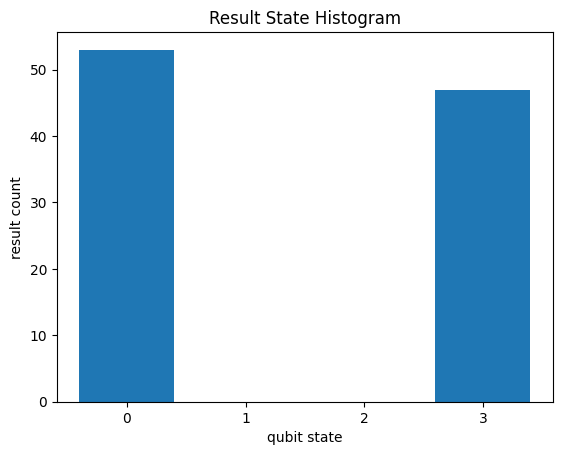

In [ ]:
# Local Simulation

print("\n✅ Local Simulation")
result = cirq.sample(
    circuit,
    repetitions=100)
print(result.histogram(key='x'))
print(result)
cirq.plot_state_histogram(result)
print(result.data)

In [ ]:
# IonQ Simulation

print("\n✅ Noiseless simulation")
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noiseless Cirq Simulation")
print(result.histogram(key='x'))
print(result)
with open('noiseless_result.pkl', 'wb') as f:
    pickle.dump(result, f)

print("\n✅ Noisy simulation")
# https://docs.ionq.com/guides/simulation-with-noise-models
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noisy Cirq Simulation",
    extra_query_params={"noise": {"model": "forte-1"}})
print(result.histogram(key='x'))
print(result)
with open('noisy_result.pkl', 'wb') as f:
    pickle.dump(result, f)


✅ Noiseless simulation
Counter({3: 50, 0: 50})
x=1101001000100111111101100111101010010001000000010100100001111000001001011101110111010001101110101101, 1101001000100111111101100111101010010001000000010100100001111000001001011101110111010001101110101101

✅ Noisy simulation
Counter({0: 54, 3: 45, 1: 1})
x=0000011111001010001000011101101010100110010111001010010011101101000010010110111001000001000110011100, 0000011111001010001000011101101010101110010111001010010011101101000010010110111001000001000110011100


In [ ]:
# IonQ Quantum Computation ⚠️

print("\n✅ Quantum simulation")
# (https://docs.ionq.com/guides/qpu-submission-checklist)
job = service.create_job(
    circuit=circuit,
    target=BACKEND,
    repetitions=100,
    name="QPU Cirq Simulation")
print(job.job_id())
print(job.status())

# Retrieve a job
#job_id = "019a7d6c-a0fb-779b-9340-8795a9a2f1c0"
#job = service.get_job(job_id)

# Get the first result from the list -  https://cloud.ionq.com/jobs
results_list = job.results()
result = results_list[0].to_cirq_result()  # Access first element
print(result.histogram(key='x'))
# Save results into file
with open('quantum_result.pkl', 'wb') as f:
    pickle.dump(result, f)


✅ Quantum simulation
019dcb89-89b9-775e-8af0-d4d49bab8474
submitted
Counter({3: 52, 0: 47, 1: 1})



✅ Comparison and Plotting of Results
 State Binary  Noiseless  Noisy  Quantum
     0     00         50     54       47
     1     01          0      1        1
     2     10          0      0        0
     3     11         50     45       52



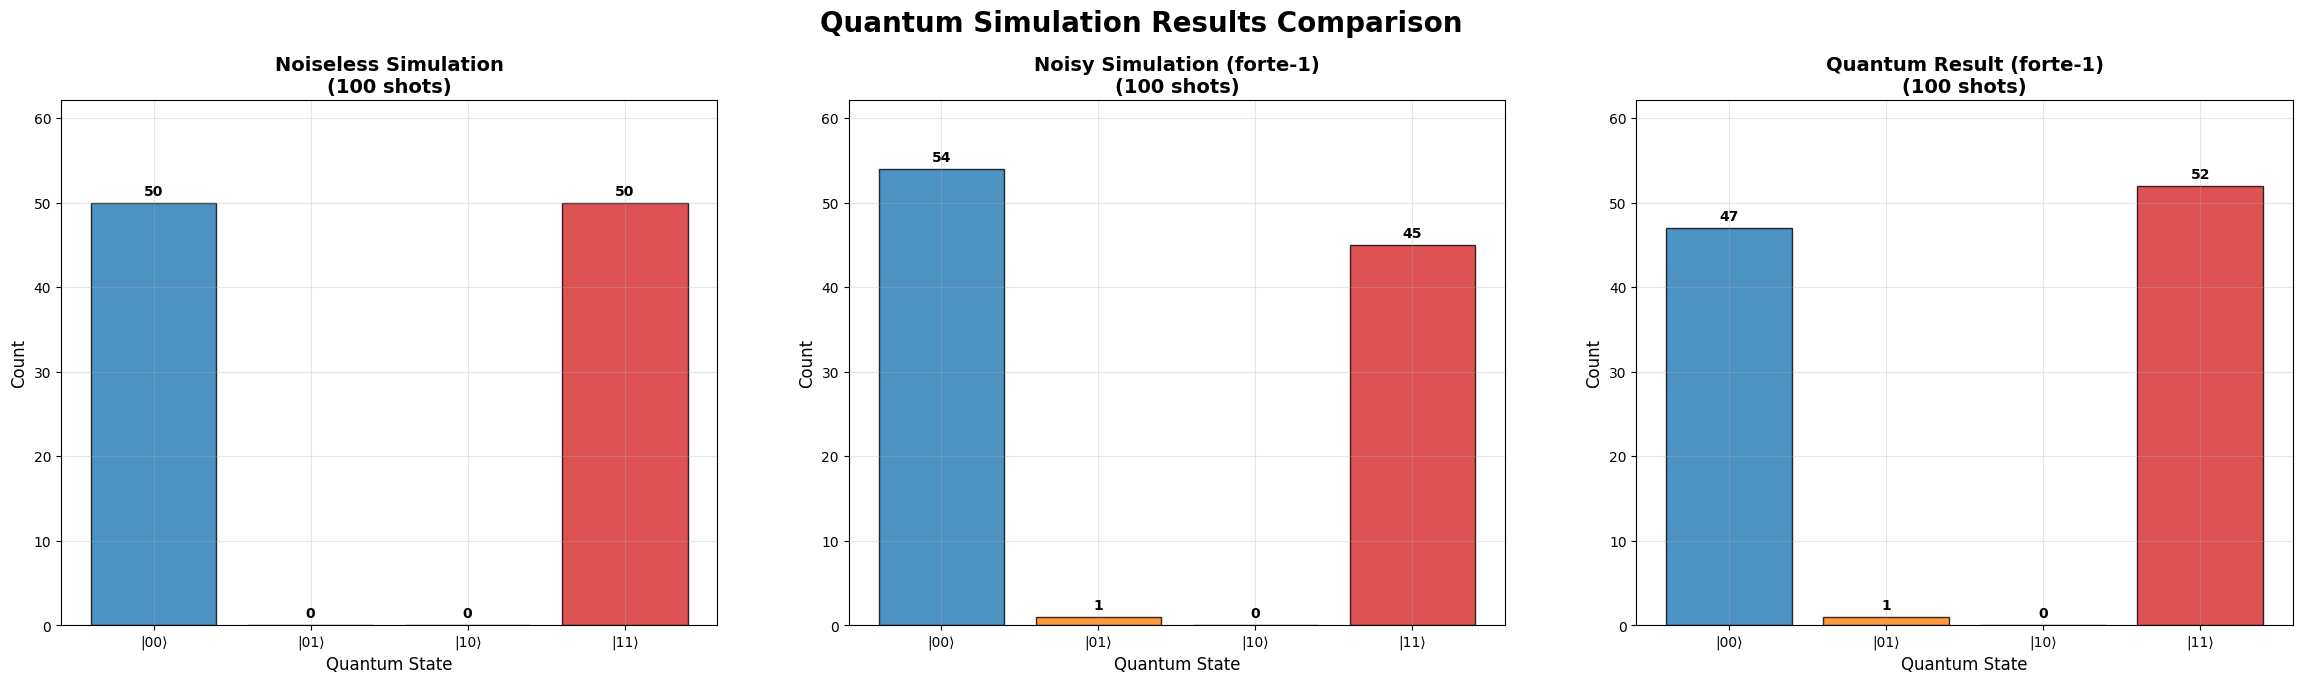

In [ ]:
# Plotting of results

print("\n✅ Comparison and Plotting of Results")
data = {}
for name in ['noiseless', 'noisy', 'quantum']:
    with open(f'{name}_result.pkl', 'rb') as f:
        result = pickle.load(f)
        data[name] = result.histogram(key='x')

# Create comparison DataFrame
states = range(4)
comparison_df = pd.DataFrame({
    'State': states,
    'Binary': [format(s, '02b') for s in states],
    'Noiseless': [data['noiseless'].get(s, 0) for s in states],
    'Noisy': [data['noisy'].get(s, 0) for s in states],
    'Quantum': [data['quantum'].get(s, 0) for s in states]
})

print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Plotting
fig = plt.figure(figsize=(24, 7))
fig.suptitle('Quantum Simulation Results Comparison', fontsize=20, fontweight='bold', y=0.98)

state_labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_configs = [
    (1, 'Noiseless', 'Noiseless Simulation\n(100 shots)'),
    (2, 'Noisy', 'Noisy Simulation (forte-1)\n(100 shots)'),
    (3, 'Quantum', 'Quantum Result (forte-1)\n(100 shots)')
]

max_count = comparison_df[['Noiseless', 'Noisy', 'Quantum']].max().max()

# Individual plots
for idx, col, title in plot_configs:
    ax = plt.subplot(1, 3, idx)
    bars = ax.bar(state_labels, comparison_df[col], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Quantum State', fontsize=12)
    ax.set_ylim(0, max_count * 1.15)
    ax.grid(True, alpha=0.3)

    # Add count labels
    for bar, count in zip(bars, comparison_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_count*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.subplots_adjust(left=0.05, bottom=0.1, right=0.98, top=0.85, wspace=0.2)
plt.show()

###### ---- IBM Quantum Computing ----

In [ ]:
# IBM libraries
!pip install qiskit qiskit-ibm-runtime qiskit[visualization] -q
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from IPython.display import display, Markdown

In [ ]:
# Connect to IBM backend
print("✅ Connect to IBM Quantum")
api_token = userdata.get('ibm-quantum')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_token)


print("\n✅ List of all backends")
available_backends = service.backends()
print("Available Quantum Backends:")
for b in available_backends:
    print(f"- {b.name} ({b.num_qubits} qubits)")

print("\n✅ Select quantum backend")
backend = service.backend('ibm_strasbourg')
# backend = service.least_busy(simulator=False, operational=True) # Choose automatically
print(f"Selected backend: {backend.name}")

#print("\n✅ Documentation")
#display(Markdown(r"Devices: https://eu-de.quantum.cloud.ibm.com/computers"))
#display(Markdown(r"Topology: https://eu-de.quantum.cloud.ibm.com/docs/de/guides/qpu-information"))
#display(Markdown(r"Jobs: https://eu-de.quantum.cloud.ibm.com/workloads"))
#display(Markdown(r"Cost: https://cloud.ibm.com/billing"))
#display(Markdown(r"Tutorials: https://eu-de.quantum.cloud.ibm.com/docs/de/tutorials"))

✅ Connect to IBM Quantum


qiskit_runtime_service._discover_account:WARNING:2026-04-26 20:49:58,662: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-26 20:50:03,517: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go), the available account instances are: einstein. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-26 20:50:03,519: Loading instance: einstein, plan: pay-as-you-go



✅ List of all backends
Available Quantum Backends:
- ibm_strasbourg (127 qubits)
- ibm_aachen (156 qubits)


qiskit_runtime_service.backends:WARNING:2026-04-26 20:50:06,790: Using instance: einstein, plan: pay-as-you-go


- ibm_brussels (127 qubits)

✅ Select quantum backend
Selected backend: ibm_strasbourg



✅ Create unequal superposition (non-uniform probability distributions) with rotation gates Rᵧ(π3)


* Final State: $|\psi_{final}\rangle = \frac{\sqrt{3}}{2\sqrt{2}}|1000\rangle + \frac{\sqrt{3}}{2\sqrt{2}}|1010\rangle + \frac{1}{2\sqrt{2}}|1101\rangle + \frac{1}{2\sqrt{2}}|1111\rangle$

* Probabilities ($P = |\text{amplitude}|^2$):: $|1000\rangle, |1010\rangle$: $P = |\frac{\sqrt{3}}{2\sqrt{2}}|^2 = 3/8 = \textbf{37.5\%}$ and $|1101\rangle, |1111\rangle$: $P = |\frac{1}{2\sqrt{2}}|^2 = 1/8 = \textbf{12.5\%}$


✅ Create the Quantum Circuit with Asymmetric State Evolution (with Unequal Superposition)


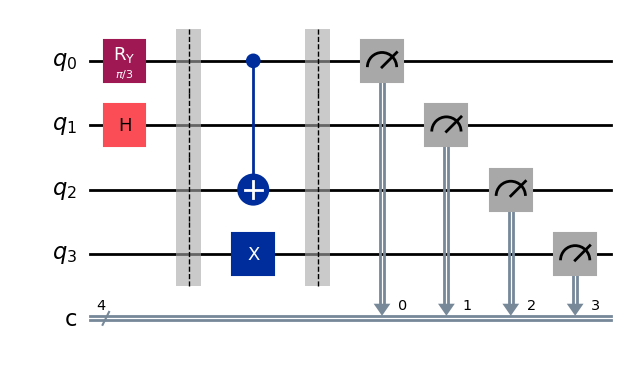

In [ ]:
# IBM Circuit Definition

# Task
print("\n✅ Create unequal superposition (non-uniform probability distributions) with rotation gates Rᵧ(π3)")
display(Markdown(r"* Final State: $|\psi_{final}\rangle = \frac{\sqrt{3}}{2\sqrt{2}}|1000\rangle + \frac{\sqrt{3}}{2\sqrt{2}}|1010\rangle + \frac{1}{2\sqrt{2}}|1101\rangle + \frac{1}{2\sqrt{2}}|1111\rangle$"))
display(Markdown(r"* Probabilities ($P = |\text{amplitude}|^2$):: $|1000\rangle, |1010\rangle$: $P = |\frac{\sqrt{3}}{2\sqrt{2}}|^2 = 3/8 = \textbf{37.5\%}$ and $|1101\rangle, |1111\rangle$: $P = |\frac{1}{2\sqrt{2}}|^2 = 1/8 = \textbf{12.5\%}$"))

print("\n✅ Create the Quantum Circuit with Asymmetric State Evolution (with Unequal Superposition)")
qc = QuantumCircuit(4, 4)
qc.ry(np.pi / 3, 0) # Replace H(0) with Ry(pi/3, 0) to create a 75%/25% split
qc.h(1)             # Keep the H on q1 for a 50/50 split
qc.barrier()
qc.cx(0, 2)
qc.x(3)
qc.barrier()
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
#print("\nIdeal Circuit Diagram:")
display(qc.draw("mpl"))


✅ Transpiled Circuit for Backend ibm_strasbourg (translates ideal circuit into one the hardware can run)


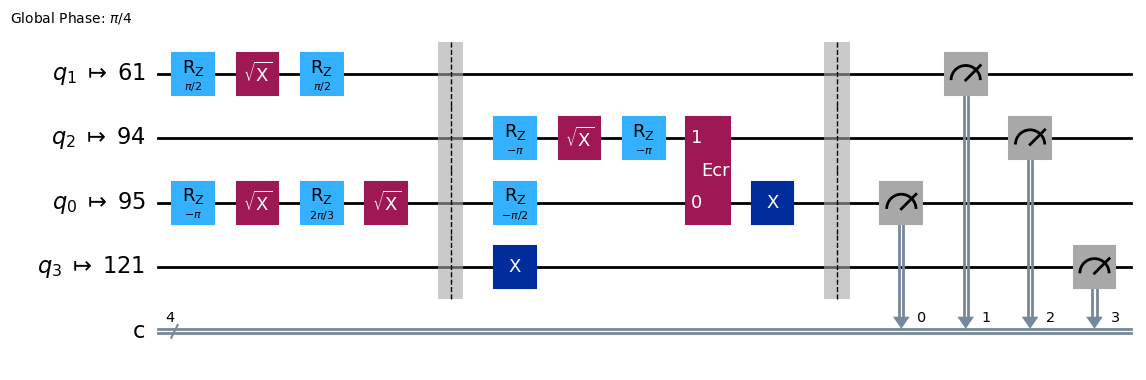

In [ ]:
# IBM Circuit Transpilation
print(f"\n✅ Transpiled Circuit for Backend {backend.name} (translates ideal circuit into one the hardware can run)")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
#print(f"\nTranspiled Circuit for {backend.name}:")
display(isa_circuit.draw("mpl"))


✅ Run local simulation
Local Simulation results (counts) with 1024 shots:
{'1010': 389, '1000': 371, '1101': 130, '1111': 134}

Probabilities:
  |1000>: 0.362 (371/1024)
  |1010>: 0.380 (389/1024)
  |1101>: 0.127 (130/1024)
  |1111>: 0.131 (134/1024)


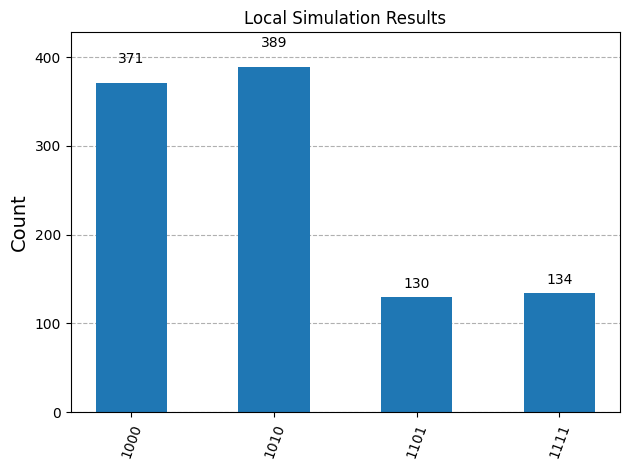

In [ ]:
#  IBM Simulation

# ----- Local Simulation ----
print("\n✅ Run local simulation")
from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.visualization import plot_histogram

local_sampler = LocalSampler() # Create local sampler
local_shots = 1024
local_job = local_sampler.run(pubs=[(qc,)], shots=local_shots) # Run circuit
local_result = local_job.result()
local_counts = local_result[0].data.c.get_counts() # Extract counts from result
print(f"Local Simulation results (counts) with {local_shots} shots:")
print(local_counts)
print("\nProbabilities:")
for bitstring, count in sorted(local_counts.items()):
    probability = count / local_shots
    print(f"  |{bitstring}>: {probability:.3f} ({count}/{local_shots})")

display(plot_histogram(local_counts, title="Local Simulation Results"))

In [ ]:
# IBM Quantum Computation ⚠️

print("\n✅ Run job on IBM quantum computer")
sampler = Sampler(mode=backend)
shots = 1024
print(f"\nSubmitting job to {backend.name}...")
job = sampler.run(pubs=[(isa_circuit,)], shots=shots) # Run transpiled 'isa_circuit', not original 'qc'
print(f"Job submitted successfully! Job ID: {job.job_id()}")

print("\n✅ Job Status")
print(f"{job.status()}")

print("\n✅ Job metrics")
print(f"{job.metrics()}")

print("\n✅ Job result")
print(f"{job.result()}")

print("\n✅ Get and display results")
result = job.result()
counts = result[0].data.c.get_counts()
print("\nMeasurement Results (Counts):")
print(counts)
plot_histogram(counts)

display(plot_histogram(counts, title="Quantum Computation Results"))


✅ Run job on IBM quantum computer

Submitting job to ibm_strasbourg...


/usr/local/lib/python3.12/dist-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1003: UserWarning: The backend ibm_strasbourg currently has a status of maintenance.
  warnings.warn(


Job submitted successfully! Job ID: d7n7l86cfkrc73cssr90

✅ Job Status
QUEUED

✅ Job metrics
{'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.46.1,qiskit-2.4.1*', 'timestamps': {'created': '2026-04-26T20:50:40.520906Z', 'finished': None, 'running': None}, 'bss': {'seconds': 0}, 'usage': {'quantum_seconds': 0, 'seconds': 0}}

✅ Job result


###### **IonQ Quantum: Two-Qubit Entangled Bell State Preparation $|\Phi^+\rangle$ (Cirq)**

In [ ]:
!pip install cirq-ionq -q
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits
import json
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files
from collections import Counter
import matplotlib.pyplot as plt
import cirq_ionq.ionq_exceptions as ionq_exceptions
print(f"Cirq version: {cirq.__version__}")
print(f"Cirq-IonQ version: {cirq_ionq.__version__}")

Cirq version: 1.6.1
Cirq-IonQ version: 1.6.1


In [ ]:
# Connect to IonQ Service and Secret Manager for Token
from google.colab import userdata
api_token = userdata.get('ionq-quantum')
service = cirq_ionq.Service(api_key=api_token)

In [ ]:
# Check Available Backends (Simulators and QPUs) --> https://cloud.ionq.com/backends/qpus
headers = {"Authorization": f"apiKey {'ionq-quantum'}"}
r = requests.get("https://api.ionq.co/v0.3/backends", headers=headers)
if r.status_code == 200:
    for i, b in enumerate(r.json(), 1):
        qt = b.get('average_queue_time', 0)
        print(f"\n{i}. {b['backend'].upper()}\n └── Type: {'QPU' if 'qpu' in b['backend'] else 'Simulator'}\n └── Status: {b['status'].upper()}\n └── Qubits: {b['qubits']}\n └── Average Queue Time: {f'{qt/3600:.1f} hours' if qt > 3600 else f'{qt/60:.1f} minutes' if qt > 60 else f'{qt} seconds'}" + (''.join([f"\n └── Available Noise Models: {', '.join(b['noise_models'])}" if 'noise_models' in b else "", f"\n └── Characterization: Available" if 'characterization_url' in b else "", f"\n └── DEGRADED SERVICE" if b.get('degraded', False) else ""])))
else: print(f"Backend check failed: {r.status_code}\nError details: {r.text}")


1. QPU.HARMONY
 └── Type: QPU
 └── Status: RETIRED
 └── Qubits: 11
 └── Average Queue Time: 0 seconds

2. QPU.ARIA-1
 └── Type: QPU
 └── Status: UNAVAILABLE
 └── Qubits: 25
 └── Average Queue Time: 3981.8 hours
 └── Characterization: Available

3. QPU.ARIA-2
 └── Type: QPU
 └── Status: RETIRED
 └── Qubits: 25
 └── Average Queue Time: 0 seconds
 └── Characterization: Available

4. SIMULATOR
 └── Type: Simulator
 └── Status: AVAILABLE
 └── Qubits: 29
 └── Average Queue Time: 0 seconds
 └── Available Noise Models: aria-1, harmony, ideal

5. QPU.FORTE-1
 └── Type: QPU
 └── Status: AVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 50198.5 hours
 └── Characterization: Available

6. QPU.FORTE-ENTERPRISE-1
 └── Type: QPU
 └── Status: UNAVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 11979.8 hours
 └── Characterization: Available


In [ ]:
# https://quantumai.google/cirq/hardware/ionq/calibrations
calibration = service.get_current_calibration()
print(calibration.fidelities())
print(calibration.timings())

**Use Case: Two-Qubit Entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) Preparation $|\Phi^+\rangle$**

* Start with two qubits, $q_0$ and $q_1$, both initialized to the $|0\rangle$ state, creating the state **$|00\rangle$**.

* Hadamard gate puts $q_0$ into a **superposition**, meaning it is equally likely to be measured as $|0\rangle$ or $|1\rangle$.
  * Hadamard on the first qubit $q_0$:  $|00\rangle \xrightarrow{H \otimes I} \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$
  * The state becomes $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$

* CNOT gate for **Entanglement** (using $q_0$ as the control and $q_1$ as the target): CNOT flips $q_1$ only if $q_0$ is $|1\rangle$  
    * If $q_0$ is $|0\rangle$, $q_1$ stays $|0\rangle$ (path $|00\rangle \to |00\rangle$).
    * If $q_0$ is $|1\rangle$, $q_1$ flips from $|0\rangle$ to $|1\rangle$ (path $|10\rangle \to |11\rangle$).
    * $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$
    * The state becomes $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$

This final state, $|\Phi^+\rangle$, is a maximally *entangled Bell state* $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ because measuring $q_0$ instantly determines $q_1$:with each outcome ('00' or '11') occurring with a $\mathbf{50\%}$ probability.
* The amplitude for $|00\rangle$ is $1/\sqrt{2}$. The probability $P('00') = |1/\sqrt{2}|^2 = 0.5$
* The amplitude for $|11\rangle$ is $1/\sqrt{2}$. The probability $P('11') = |1/\sqrt{2}|^2 = 0.5$

In [ ]:
# Define Circuit - Two-Qubit Bell state Preparation |Φ+⟩
q0, q1 = cirq.LineQubit.range(2)
circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1, key='x'))
print(circuit)

0: ───H───@───M('x')───
          │   │
1: ───────X───M────────


In [ ]:
# Theoretical Calculation (Exact probability distribution based on state vector simulation)
def calculate_exact_noiseless_probabilities(circuit: cirq.Circuit) -> dict:

    # 1. Circuit Preparation and Measurement Removal
    """
    The purpose of a state vector simulation is to find the final quantum state before
    the measurement operation collapses it. Removing the terminal cirq.measure gate ensures
    the simulator provides the final superposition state |Φ⁺⟩
    """
    circuit_without_measurements = cirq.drop_terminal_measurements(circuit)

    # 2. State Vector Simulation
    simulator = cirq.Simulator()
    result = simulator.simulate(circuit_without_measurements)
    final_state_vector = result.final_state_vector

    exact_counts = {}

    # 3. Probability and Count Calculation
    for i, amplitude in enumerate(final_state_vector):
        probability = np.abs(amplitude)**2
        count = round(probability * 100)  # Convert to counts for number of shots ('repetitions=')

    # 4. Result Mapping
        if count > 0:
            exact_counts[i] = count  # Use integer key like {0: 50, 3: 50}
    return exact_counts
theoretical_prediction = calculate_exact_noiseless_probabilities(circuit)

print("--- Theoretical Count Distribution ---")
print(f"Counter({theoretical_prediction})")
theoretical_counter = Counter(theoretical_prediction) # mock counter object to match format

# Store results for later comparison
with open('theoretical_result.pkl', 'wb') as f:
    pickle.dump(theoretical_counter, f)

--- Theoretical Count Distribution ---
Counter({0: 50, 3: 50})


In [ ]:
# Noiseless simulation
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noiseless Cirq Simulation")
print(result.histogram(key='x'))
print(result)
with open('noiseless_result.pkl', 'wb') as f:
    pickle.dump(result, f)

Counter({3: 53, 0: 47})
x=1101101100010001011111001101111100111001101101101110001000110010100101000000011111101001100110100110, 1101101100010001011111001101111100111001101101101110001000110010100101000000011111101001100110100110


In [ ]:
# Noisy simulation
# https://docs.ionq.com/guides/simulation-with-noise-models
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noisy Cirq Simulation",
    extra_query_params={"noise": {"model": "forte-1"}})
print(result.histogram(key='x'))
print(result)
with open('noisy_result.pkl', 'wb') as f:
    pickle.dump(result, f)

Counter({0: 56, 3: 43, 2: 1})
x=0100101101100001110001000100001001101010011000010011010001101101100100100001010110110101111010011000, 0100101101100001110001000100001001101010011000010011010001101101100100100001010110110101111000011000


In [ ]:
# Quantum Simulation
# (https://docs.ionq.com/guides/qpu-submission-checklist)
job = service.create_job(
    circuit=circuit,
    target="qpu.forte-1", # forte-enterprise-1, aria-1
    repetitions=100,
    name="QPU Cirq Simulation")
print(job.job_id())
print(job.status())

019a7d6c-a0fb-779b-9340-8795a9a2f1c0
submitted


In [ ]:
# See job queue: https://cloud.ionq.com/jobs
job_id = "019a7d6c-a0fb-779b-9340-8795a9a2f1c0"
print(job.status())

completed


In [ ]:
# Retrieve a job
#job_id = "019a7d6c-a0fb-779b-9340-8795a9a2f1c0"
#job = service.get_job(job_id)

# Get the first result from the list
results_list = job.results()
result = results_list[0].to_cirq_result()  # Access first element
print(result.histogram(key='x'))
# Save results into file
with open('quantum_result.pkl', 'wb') as f:
    pickle.dump(result, f)

Counter({0: 55, 3: 43, 1: 1, 2: 1})



RESULTS:
 State Binary  Theory  Noiseless  Noisy  Quantum
     0     00      50         47     56       55
     1     01       0          0      0        1
     2     10       0          0      1        1
     3     11      50         53     43       43



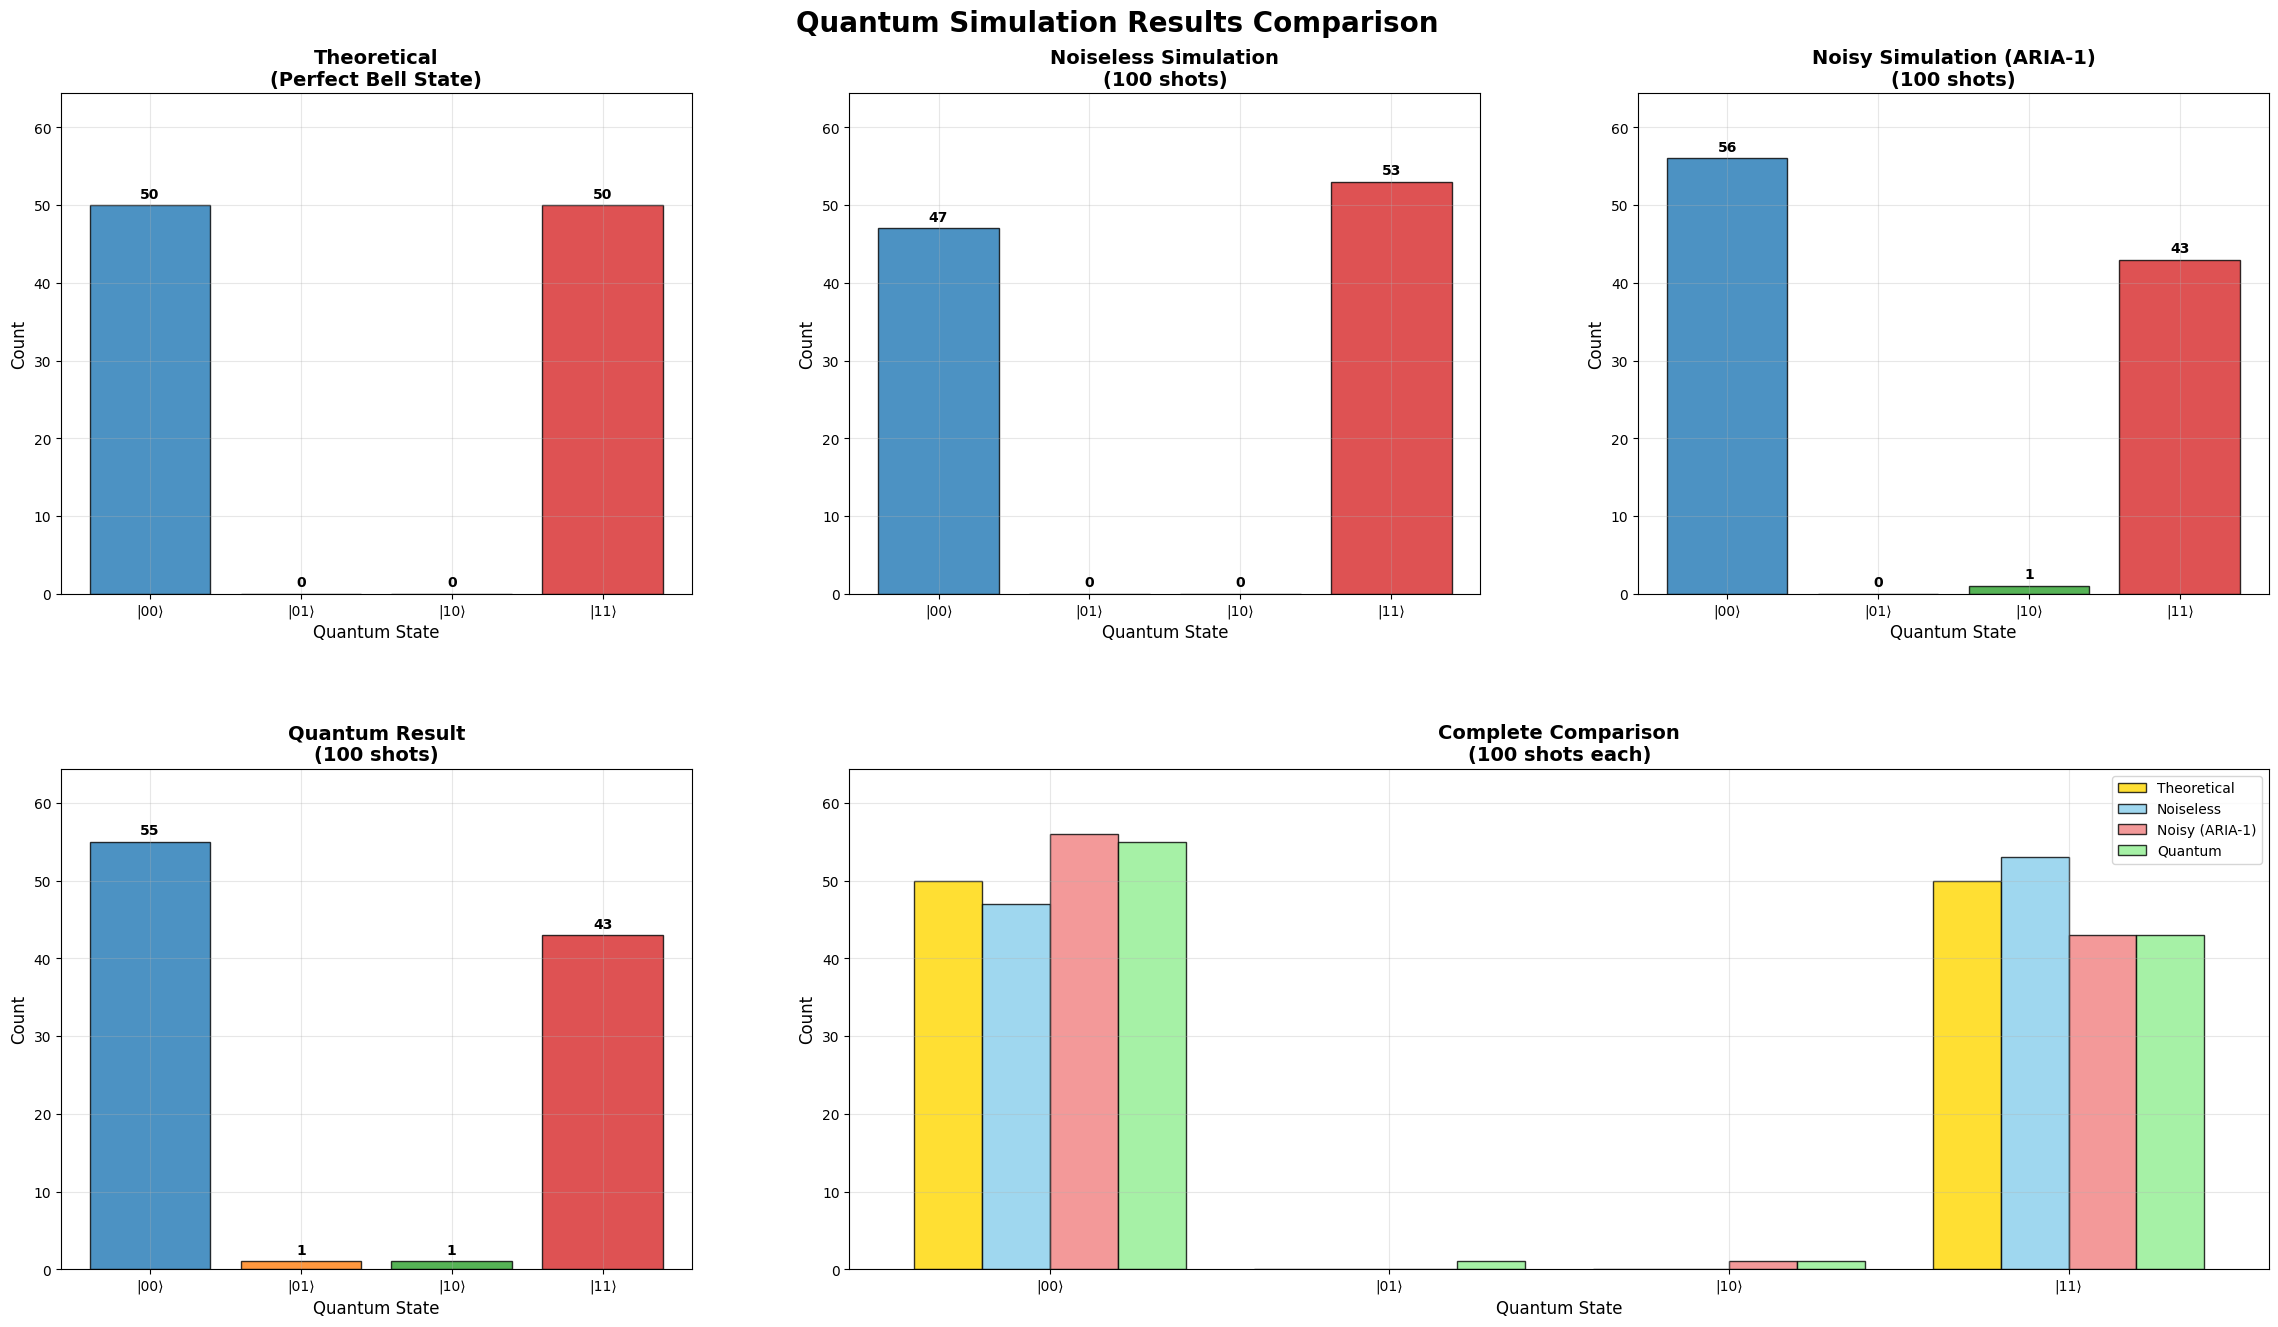

In [ ]:
# @title Comparison of Results
data = {}
for name in ['noiseless', 'noisy', 'theoretical', 'quantum']:
    with open(f'{name}_result.pkl', 'rb') as f:
        result = pickle.load(f)
        data[name] = result.histogram(key='x') if hasattr(result, 'histogram') else result

# Create comparison DataFrame
states = range(4)
comparison_df = pd.DataFrame({
    'State': states,
    'Binary': [format(s, '02b') for s in states],
    'Theory': [data['theoretical'].get(s, 0) for s in states],
    'Noiseless': [data['noiseless'].get(s, 0) for s in states],
    'Noisy': [data['noisy'].get(s, 0) for s in states],
    'Quantum': [data['quantum'].get(s, 0) for s in states]
})

print("\nRESULTS:\n" + "="*50)
print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Plotting
fig = plt.figure(figsize=(24, 14))
fig.suptitle('Quantum Simulation Results Comparison', fontsize=20, fontweight='bold', y=0.98)

state_labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_configs = [
    (1, 'Theory', 'Theoretical\n(Perfect Bell State)'),
    (2, 'Noiseless', 'Noiseless Simulation\n(100 shots)'),
    (3, 'Noisy', 'Noisy Simulation (ARIA-1)\n(100 shots)'),
    (4, 'Quantum', 'Quantum Result\n(100 shots)')
]

max_count = comparison_df[['Theory', 'Noiseless', 'Noisy', 'Quantum']].max().max()

# Individual plots
for idx, col, title in plot_configs:
    ax = plt.subplot(2, 3, idx)
    bars = ax.bar(state_labels, comparison_df[col], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Quantum State', fontsize=12)
    ax.set_ylim(0, max_count * 1.15)
    ax.grid(True, alpha=0.3)

    # Add count labels
    for bar, count in zip(bars, comparison_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_count*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Comparison plot
ax5 = plt.subplot(2, 3, (5, 6))
x = np.arange(4)
width = 0.2
plot_data = [
    ('Theory', 'Theoretical', 'gold'),
    ('Noiseless', 'Noiseless', 'skyblue'),
    ('Noisy', 'Noisy (ARIA-1)', 'lightcoral'),
    ('Quantum', 'Quantum', 'lightgreen')
]

for i, (col, label, color) in enumerate(plot_data):
    ax5.bar(x + (i-1.5)*width, comparison_df[col], width, label=label,
            color=color, alpha=0.8, edgecolor='black')

ax5.set_title('Complete Comparison\n(100 shots each)', fontsize=14, fontweight='bold')
ax5.set_ylabel('Count', fontsize=12)
ax5.set_xlabel('Quantum State', fontsize=12)
ax5.set_xticks(x)
ax5.set_xticklabels(state_labels)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_ylim(0, max_count * 1.15)

plt.subplots_adjust(left=0.06, bottom=0.08, right=0.98, top=0.92, wspace=0.25, hspace=0.35)
plt.show()

###### **IBM Quantum: Create unequal superposition with rotation gates $R_y(\pi\ 3)$ (Qiskit)**

In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit[visualization] -q
import matplotlib.pyplot as plt
import numpy as np
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [ ]:
# 1. Connect to IBM Quantum
api_token = userdata.get('ibm-quantum')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_token)

qiskit_runtime_service._discover_account:WARNING:2026-01-16 15:35:06,514: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-16 15:35:09,067: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go), the available account instances are: einstein. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [ ]:
# 2. List of all backends
available_backends = service.backends()
print("Available Quantum Backends:")
for b in available_backends:
    print(f"- {b.name} ({b.num_qubits} qubits)")

qiskit_runtime_service.backends:WARNING:2026-01-16 15:33:27,518: Loading instance: einstein, plan: pay-as-you-go


Available Quantum Backends:
- ibm_strasbourg (127 qubits)
- ibm_aachen (156 qubits)
- ibm_brussels (127 qubits)


In [ ]:
# 3. Select one backend directly
backend = service.backend('ibm_strasbourg')
# backend = service.least_busy(simulator=False, operational=True) # Choose automatically
print(f"Selected backend: {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-01-16 15:34:43,808: Using instance: einstein, plan: pay-as-you-go


Selected backend: ibm_strasbourg


**Use Case: Unequal Superposition Experiment**

Creating non-uniform probability distributions by combining standard superposition gates with rotation gates.

* **Circuit:**
    1.  **Unequal Superposition:** $R_y(\pi/3)$ on $q_0 \rightarrow \frac{\sqrt{3}}{2}|0\rangle + \frac{1}{2}|1\rangle$.
    2.  **Equal Superposition:** $H$ on $q_1 \rightarrow \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.
    3.  **Bit-Flip:** $X$ on $q_3$ flips MSB $|0...\rangle \rightarrow |1...\rangle$.
    4.  **Entanglement:** $CX_{0,2}$ flips $q_2$ if $q_0$ is $|1\rangle$.
* **Final State:** $|\psi_{final}\rangle = \frac{\sqrt{3}}{2\sqrt{2}}|1000\rangle + \frac{\sqrt{3}}{2\sqrt{2}}|1010\rangle + \frac{1}{2\sqrt{2}}|1101\rangle + \frac{1}{2\sqrt{2}}|1111\rangle$
* **Probabilities ($P = |\text{amplitude}|^2$):**
    * $|1000\rangle, |1010\rangle$: $P = |\frac{\sqrt{3}}{2\sqrt{2}}|^2 = 3/8 = \textbf{37.5\%}$
    * $|1101\rangle, |1111\rangle$: $P = |\frac{1}{2\sqrt{2}}|^2 = 1/8 = \textbf{12.5\%}$


Ideal Circuit Diagram:


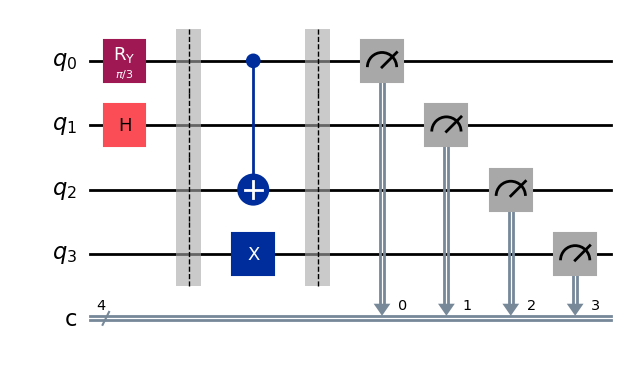

In [ ]:
# 4. Create the Quantum Circuit with Asymmetric State Evolution (with Unequal Superposition)
qc = QuantumCircuit(4, 4)
qc.ry(np.pi / 3, 0) # Replace H(0) with Ry(pi/3, 0) to create a 75%/25% split
qc.h(1)             # Keep the H on q1 for a 50/50 split
qc.barrier()
qc.cx(0, 2)
qc.x(3)
qc.barrier()
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
print("\nIdeal Circuit Diagram:")
display(qc.draw("mpl"))


Transpiled Circuit for ibm_brussels:


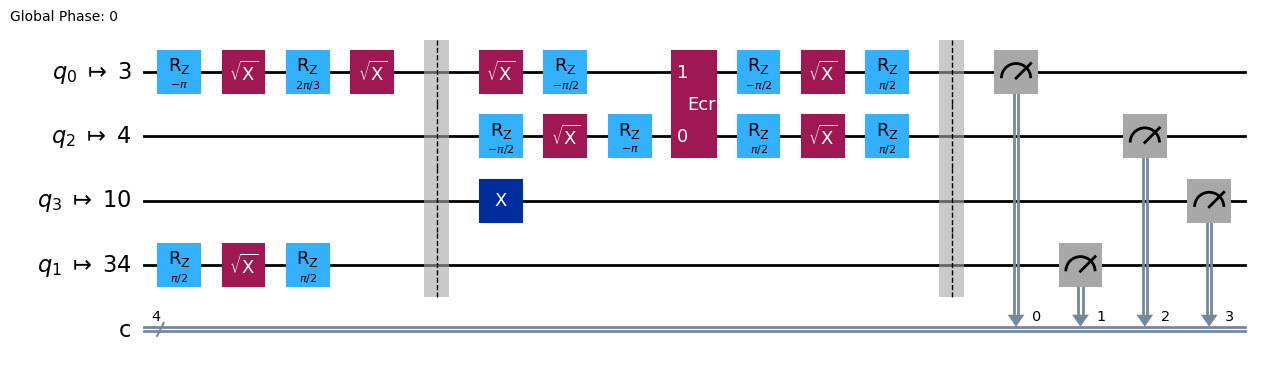

In [ ]:
# 5. Transpile circuit for backend (translates ideal circuit into one the hardware can run)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
print(f"\nTranspiled Circuit for {backend.name}:")
display(isa_circuit.draw("mpl"))

In [ ]:
# 6. Run job on IBM quantum computer
sampler = Sampler(mode=backend)
shots = 1024
print(f"\nSubmitting job to {backend.name}...")
job = sampler.run(pubs=[(isa_circuit,)], shots=shots) # Run transpiled 'isa_circuit', not original 'qc'
print(f"Job submitted successfully! Job ID: {job.job_id()}")


Submitting job to ibm_brussels...
Job submitted successfully! Job ID: d3615tl7ibtc73dlifgg


In [ ]:
job.status()

'DONE'

In [ ]:
job.metrics()

{'timestamps': {'created': '2025-09-18T14:11:02.899474Z',
  'finished': '2025-09-18T14:15:53.524337Z',
  'running': '2025-09-18T14:15:36.902052Z'},
 'bss': {'seconds': 3},
 'usage': {'quantum_seconds': 3, 'seconds': 3},
 'qiskit_version': 'qiskit_ibm_runtime-0.41.1,qiskit-2.1.2*',
 'caller': 'qiskit_ibm_runtime~sampler.py'}

In [ ]:
job.result()

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=4>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-09-18 14:15:51', stop='2025-09-18 14:15:53', size=1024>)])}, 'version': 2})


Measurement Results (Counts):
{'1000': 390, '1010': 350, '1101': 121, '1110': 4, '1111': 141, '0010': 4, '0111': 2, '1001': 1, '1100': 5, '1011': 2, '0101': 1, '0000': 3}

Result Histogram:


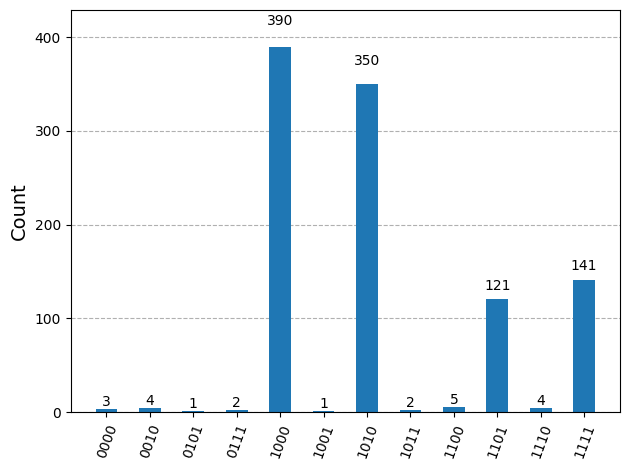

In [ ]:
# 7. Get and display results
result = job.result()
counts = result[0].data.c.get_counts()
print("\nMeasurement Results (Counts):")
print(counts)
plot_histogram(counts)


Local Simulation results (counts) with 1024 shots:
{'1101': 118, '1111': 131, '1000': 388, '1010': 387}

Local Simulation Probabilities:
  |1000>: 0.379 (388/1024)
  |1010>: 0.378 (387/1024)
  |1101>: 0.115 (118/1024)
  |1111>: 0.128 (131/1024)

Local Simulation Histogram:


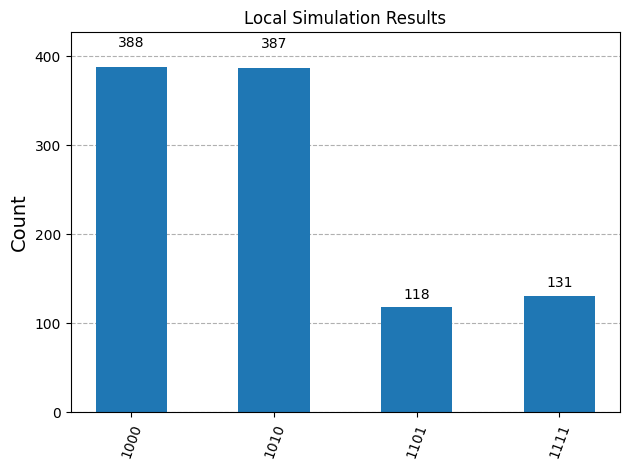

In [ ]:
# Appendix: Run local simulation
from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.visualization import plot_histogram

local_sampler = LocalSampler() # Create local sampler
local_shots = 1024
local_job = local_sampler.run(pubs=[(qc,)], shots=local_shots) # Run circuit
local_result = local_job.result()
local_counts = local_result[0].data.c.get_counts() # Extract counts from result
print(f"\nLocal Simulation results (counts) with {local_shots} shots:")
print(local_counts)
print("\nProbabilities:")
for bitstring, count in sorted(local_counts.items()):
    probability = count / local_shots
    print(f"  |{bitstring}>: {probability:.3f} ({count}/{local_shots})")

display(plot_histogram(local_counts, title="Local Simulation Results"))

Devices: https://eu-de.quantum.cloud.ibm.com/computers

Topology: https://eu-de.quantum.cloud.ibm.com/docs/de/guides/qpu-information

Jobs: https://eu-de.quantum.cloud.ibm.com/workloads

Cost: https://cloud.ibm.com/billing

Tutorials: https://eu-de.quantum.cloud.ibm.com/docs/de/tutorials

###### **Alice & Bob Quantum: Measure bit-flip probability of a single qubit after a 1ms delay (Qiskit)**

In [ ]:
!pip install -U qiskit-alice-bob-provider -q
from google.colab import userdata
from qiskit_alice_bob_provider import AliceBobRemoteProvider
from qiskit import QuantumCircuit, transpile

In [ ]:
# 1. Retrieve API key and connect to Alice & Bob
api_token = userdata.get('alicebob')
provider = AliceBobRemoteProvider(api_key=api_token)

In [ ]:
# 2. List available backends
for backend in provider.backends():
    print(backend.name)

EMU:1Q:LESCANNE_2020
QPU:1Q:BOSON_4A
QPU:1Q:BOSON_4B
QPU:1Q:BOSON_4C
EMU:6Q:PHYSICAL_CATS
EMU:40Q:PHYSICAL_CATS
EMU:40Q:LOGICAL_TARGET
EMU:40Q:LOGICAL_NOISELESS
EMU:15Q:LOGICAL_EARLY


In [ ]:
# 3. Select backend (QPU quantum or EMU emulator)
backend = provider.get_backend('EMU:6Q:PHYSICAL_CATS', average_nb_photons=10.0)
print(f"Selected backend: {backend.name}")

Selected backend: EMU:6Q:PHYSICAL_CATS


In [ ]:
# 4. Define Quantum Circuit
qc = QuantumCircuit(1, 1)
qc.initialize('1', 0)
qc.delay(duration=1, qarg=0, unit='ms')
qc.measure(0, 0) # Measures bit-flip probability of single qubit after a 1ms delay
print(qc.draw())

     ┌───────────────┐┌──────────────┐┌─┐
  q: ┤ Initialize(1) ├┤ Delay(1[ms]) ├┤M├
     └───────────────┘└──────────────┘└╥┘
c: 1/══════════════════════════════════╩═
                                       0 


In [ ]:
# 6. Transpile circuit to specific backend to ensure correct error-correction properties
transpiled = transpile(qc, backend)
print(transpiled.draw())

     ┌───────────────┐┌─────────────────┐┌─┐
   q ┤ Initialize(1) ├┤ Delay(0.001[s]) ├┤M├
     └───────────────┘└─────────────────┘└╥┘
c: 1/═════════════════════════════════════╩═
                                          0 


In [ ]:
# 7. Run circuit on Felis Cloud
job = backend.run(transpiled, shots=1000)

In [ ]:
# 8. Get results
res = job.result()
print(f"Job Status: {job.status()}")
print(f'Total counts: {res.get_counts()}')

Job Status: JobStatus.DONE
Total counts: {'1': 1000}


In [ ]:
# Console: https://api-gcp.alice-bob.com/console
# Backend: https://felis.alice-bob.com/docs/backends/about_backends/
# Status:  https://felis.alice-bob.com/docs/felis_cloud/hardware_availability_schedule/
# Samples: https://github.com/Alice-Bob-SW/felis/tree/main/samples